# Federated and Explainable AI for Stroke-Status Classification Using Public BRFSS Data

**UREC1-aligned Kaggle notebook**

**Dataset:** *Indicators of Heart Disease (2022 UPDATE)* by Kamil Pytlak  
**Selected file:** `heart_2020_cleaned.csv`  
**Kaggle:** https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/data  
**Dataset licence stated in the approved UREC1:** CC0: Public Domain  
**Original source:** CDC 2020 Behavioral Risk Factor Surveillance System (BRFSS)  
**Target:** `Stroke` (`Yes` = 1, `No` = 0)

## Research purpose

This notebook implements the methodology described in the UREC1:

- audit the dataset and class imbalance;
- use leakage-safe train/validation/test separation;
- compare centralised Logistic Regression, Random Forest and gradient-boosted trees;
- report accuracy **and** minority-class metrics, PR-AUC, ROC-AUC, macro-F1 and balanced accuracy;
- assess probability calibration using Brier score and calibration plots;
- create a centralised neural-network baseline;
- simulate federated learning with controlled non-IID clients and Federated Averaging (FedAvg);
- compare centralised and federated neural networks using the same locked test set;
- evaluate subgroup performance for `Sex`, `AgeCategory` and `Race`;
- explain the strongest centralised model using SHAP;
- save reproducible model artefacts and result tables.

> **Important:** The study classifies the self-reported `Stroke` field in cross-sectional survey data. It does not diagnose patients or make a clinically validated prediction of future stroke. SHAP explanations describe model behaviour and must not be interpreted as causal or clinical evidence.

### About the requested 90%+ accuracy

Because this dataset is strongly imbalanced, overall accuracy alone can be misleading. The notebook searches for a validation-set decision threshold that preserves **at least 92% validation accuracy where possible while maximising minority-class F1**. The 92% validation floor provides a safety margin for the requested 90%+ locked-test accuracy. The final test set remains locked. Therefore, no scientifically valid notebook can guarantee a particular unseen test accuracy in advance; the notebook prints an explicit pass/warning after final testing and never tunes on the test set.

## Final UREC1 completion additions

This final version also implements the remaining UREC1 documentation and export requirements:

- formal 18-variable data dictionary;
- explicit plausibility screening without automatically deleting plausible extremes;
- full software and hardware version records;
- separate confusion matrices for the centralised and federated neural networks;
- additional training/federated/client/model-comparison charts;
- automatic saving of every displayed Matplotlib figure;
- separate ZIP archives for all figures and all non-image analytical outputs.

**Run All once in Kaggle before submission.** The last cell creates both downloadable ZIP files from that same execution.


In [1]:
# 1. Imports, reproducibility and dedicated export folders
import os
import sys
import json
import re
import math
import random
import warnings
import shutil
import platform
import hashlib
from pathlib import Path
from glob import glob
from importlib import metadata as importlib_metadata

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Validation-only accuracy floor. The locked test set is never used for tuning.
MIN_VALIDATION_ACCURACY = 0.92

OUTPUT_DIR = Path("/kaggle/working/urec1_outputs")
FIGURE_DIR = Path("/kaggle/working/urec1_figures")

for directory in [OUTPUT_DIR, FIGURE_DIR]:
    if directory.exists():
        shutil.rmtree(directory)
    directory.mkdir(parents=True, exist_ok=True)

# Automatically save every displayed Matplotlib figure to FIGURE_DIR.
# This guarantees that the final figures ZIP contains every graph/chart/image
# produced through plt.show(), including SHAP and confusion-matrix figures.
_ORIGINAL_PLT_SHOW = plt.show
_FIGURE_COUNTER = 0

def _safe_filename(text):
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")
    return text[:90] or "figure"

def _save_and_show(*args, **kwargs):
    global _FIGURE_COUNTER
    fig = plt.gcf()
    if fig is not None and len(fig.axes) > 0:
        _FIGURE_COUNTER += 1
        title = ""
        for ax in fig.axes:
            if ax.get_title():
                title = ax.get_title()
                break
        file_name = f"{_FIGURE_COUNTER:03d}_{_safe_filename(title)}.png"
        fig.savefig(
            FIGURE_DIR / file_name,
            dpi=180,
            bbox_inches="tight"
        )
    return _ORIGINAL_PLT_SHOW(*args, **kwargs)

plt.show = _save_and_show

print("Python:", sys.version.split()[0])
print("Output folder:", OUTPUT_DIR)
print("Figure folder:", FIGURE_DIR)

Python: 3.12.13
Output folder: /kaggle/working/urec1_outputs
Figure folder: /kaggle/working/urec1_figures


In [2]:
# 2. Machine-learning imports and complete software-version record
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.calibration import CalibrationDisplay
import joblib

try:
    import xgboost
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    xgboost = None
    XGBOOST_AVAILABLE = False
    print("XGBoost import failed:", exc)

def safe_package_version(name):
    try:
        return importlib_metadata.version(name)
    except Exception:
        return "not available"

software_versions = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": mpl.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": safe_package_version("xgboost"),
    "joblib": safe_package_version("joblib"),
    "torch": safe_package_version("torch"),
    "shap": safe_package_version("shap"),
}

software_versions_df = pd.DataFrame(
    [{"software": k, "version": v} for k, v in software_versions.items()]
)
display(software_versions_df)

software_versions_df.to_csv(
    OUTPUT_DIR / "software_versions.csv",
    index=False
)
with open(OUTPUT_DIR / "software_versions.json", "w") as f:
    json.dump(software_versions, f, indent=2)

print("XGBoost available:", XGBOOST_AVAILABLE)

,software,version
0,python,3.12.13
1,platform,Linux-6.12.90+-x86_64-with-glibc2.35
2,numpy,2.0.2
3,pandas,2.3.3
4,matplotlib,3.10.0
5,scikit-learn,1.6.1
6,xgboost,3.2.0
7,joblib,1.5.3
8,torch,2.10.0+cpu
9,shap,0.51.0


XGBoost available: True


In [3]:
# 3. Load the exact UREC1 dataset file and record provenance
candidate_paths = glob("/kaggle/input/**/heart_2020_cleaned.csv", recursive=True)

if not candidate_paths:
    raise FileNotFoundError(
        "heart_2020_cleaned.csv was not found under /kaggle/input/. "
        "In Kaggle, click Add Input and attach the dataset "
        "'Personal Key Indicators of Heart Disease'."
    )

DATA_PATH = candidate_paths[0]
df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

assert "Stroke" in df.columns, "UREC1 target column 'Stroke' is missing."
assert df.shape == (319795, 18), (
    f"Expected UREC1 dataset shape (319795, 18), found {df.shape}."
)

sha256 = hashlib.sha256()
with open(DATA_PATH, "rb") as f:
    for block in iter(lambda: f.read(1024 * 1024), b""):
        sha256.update(block)
DATA_SHA256 = sha256.hexdigest()

dataset_provenance = {
    "dataset_title": "Indicators of Heart Disease (2022 UPDATE)",
    "kaggle_publisher": "Kamil Pytlak",
    "selected_file": Path(DATA_PATH).name,
    "records": int(df.shape[0]),
    "variables": int(df.shape[1]),
    "original_source": "CDC 2020 Behavioral Risk Factor Surveillance System (BRFSS)",
    "licence_as_recorded_in_UREC1": "CC0: Public Domain",
    "dataset_url": "https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/data",
    "target": "Stroke",
    "sha256": DATA_SHA256,
}
with open(OUTPUT_DIR / "dataset_provenance.json", "w") as f:
    json.dump(dataset_provenance, f, indent=2)

print("Dataset SHA-256:", DATA_SHA256)

Loaded: /kaggle/input/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/2020/heart_2020_cleaned.csv
Shape: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


Dataset SHA-256: 90a1e2e8bdcb4aba54314a41d35d2ac3be4763e459df33951e08e415f527f5a8



## Formal data-dictionary review

The UREC1 explicitly states that the method includes a **data-dictionary review**. The following table documents all 18 selected fields, their analytical type, a concise operational description and their role in this study. The Kaggle/CDC documentation remains the authoritative source for exact questionnaire wording.

`Stroke` is the binary target. `Sex`, `AgeCategory` and `Race` are also retained for the pre-specified subgroup-performance audit. No feature is interpreted causally.


In [4]:

# 3A. Formal 18-variable data dictionary
data_dictionary = pd.DataFrame([
    ["HeartDisease", "Categorical (Yes/No)", "Self-reported heart-disease indicator", "Predictor"],
    ["BMI", "Numeric", "Body mass index", "Predictor"],
    ["Smoking", "Categorical (Yes/No)", "Smoking-status indicator", "Predictor"],
    ["AlcoholDrinking", "Categorical (Yes/No)", "Alcohol-drinking indicator in the cleaned dataset", "Predictor"],
    ["Stroke", "Categorical (Yes/No)", "Self-reported stroke-status field", "Target"],
    ["PhysicalHealth", "Numeric", "Reported poor physical-health days in the reference month", "Predictor"],
    ["MentalHealth", "Numeric", "Reported poor mental-health days in the reference month", "Predictor"],
    ["DiffWalking", "Categorical (Yes/No)", "Difficulty walking / climbing-stairs indicator", "Predictor"],
    ["Sex", "Categorical", "Reported sex category", "Predictor + subgroup audit"],
    ["AgeCategory", "Ordered categorical", "Reported age band", "Predictor + subgroup audit"],
    ["Race", "Categorical", "Reported race category in the cleaned file", "Predictor + subgroup audit"],
    ["Diabetic", "Categorical", "Reported diabetes-status category", "Predictor"],
    ["PhysicalActivity", "Categorical (Yes/No)", "Physical-activity indicator", "Predictor"],
    ["GenHealth", "Ordered categorical", "Self-rated general-health category", "Predictor"],
    ["SleepTime", "Numeric", "Reported average sleep hours", "Predictor"],
    ["Asthma", "Categorical (Yes/No)", "Reported asthma indicator", "Predictor"],
    ["KidneyDisease", "Categorical (Yes/No)", "Reported kidney-disease indicator", "Predictor"],
    ["SkinCancer", "Categorical (Yes/No)", "Reported skin-cancer indicator", "Predictor"],
], columns=[
    "variable",
    "analytical_type",
    "operational_description",
    "study_role",
])

assert set(data_dictionary["variable"]) == set(df.columns)
display(data_dictionary)
data_dictionary.to_csv(
    OUTPUT_DIR / "data_dictionary.csv",
    index=False
)


,variable,analytical_type,operational_description,study_role
0,HeartDisease,Categorical (Yes/No),Self-reported heart-disease indicator,Predictor
1,BMI,Numeric,Body mass index,Predictor
2,Smoking,Categorical (Yes/No),Smoking-status indicator,Predictor
3,AlcoholDrinking,Categorical (Yes/No),Alcohol-drinking indicator in the cleaned dataset,Predictor
4,Stroke,Categorical (Yes/No),Self-reported stroke-status field,Target
5,PhysicalHealth,Numeric,Reported poor physical-health days in the refe...,Predictor
6,MentalHealth,Numeric,Reported poor mental-health days in the refere...,Predictor
7,DiffWalking,Categorical (Yes/No),Difficulty walking / climbing-stairs indicator,Predictor
8,Sex,Categorical,Reported sex category,Predictor + subgroup audit
9,AgeCategory,Ordered categorical,Reported age band,Predictor + subgroup audit


## Dataset-governance audit

The UREC1 identifies `heart_2020_cleaned.csv` as a cleaned public-use derivative of CDC BRFSS data. The code below records the dataset dimensions, variables, missingness and exact-row duplicates.

**Exact duplicate profiles are audited but not automatically deleted.** This dataset has no respondent identifier, so two identical 18-variable profiles cannot automatically be assumed to be the same person. Removing them simply because their observed profiles match could distort the survey distribution.

In [5]:
# 4. Dataset audit: variables, missingness, duplicates, target
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_pct': (100 * df.isna().mean()).round(4),
    'unique_n': df.nunique(dropna=False),
})
display(audit)

duplicate_profiles = int(df.duplicated().sum())
print('Exact duplicate 18-variable profiles:', duplicate_profiles)
print('Missing cells:', int(df.isna().sum().sum()))

print('\nTarget distribution:')
target_counts = df['Stroke'].value_counts(dropna=False)
display(target_counts.to_frame('count'))
target_pct = (100 * df['Stroke'].value_counts(normalize=True)).round(3)
display(target_pct.to_frame('percent'))

,dtype,missing_n,missing_pct,unique_n
HeartDisease,object,0,0.0,2
BMI,float64,0,0.0,3604
Smoking,object,0,0.0,2
AlcoholDrinking,object,0,0.0,2
Stroke,object,0,0.0,2
PhysicalHealth,float64,0,0.0,31
MentalHealth,float64,0,0.0,31
DiffWalking,object,0,0.0,2
Sex,object,0,0.0,2
AgeCategory,object,0,0.0,13


Exact duplicate 18-variable profiles: 18078
Missing cells: 0

Target distribution:


,count
Stroke,
No,307726
Yes,12069


,percent
Stroke,
No,96.226
Yes,3.774



## Explicit plausibility screening

The UREC1 commits to checks for **implausible values**. The screening below uses broad, transparent ranges and category checks. It does **not** automatically delete unusual observations; plausible extremes are retained because statistical outliers are not necessarily data errors.


,check,value
0,records,319795
1,variables,18
2,missing_cells,0
3,exact_duplicate_profiles,18078


,variable,rule,invalid_n,invalid_pct,decision
0,BMI,Broad screening range 10–100,0,0.0,Review only; no automatic deletion
1,PhysicalHealth,0–30 days,0,0.0,Review only; no automatic deletion
2,MentalHealth,0–30 days,0,0.0,Review only; no automatic deletion
3,SleepTime,1–24 hours,0,0.0,Review only; no automatic deletion
4,HeartDisease,Expected categories: Yes / No,0,0.0,No unexpected categories
5,Smoking,Expected categories: Yes / No,0,0.0,No unexpected categories
6,AlcoholDrinking,Expected categories: Yes / No,0,0.0,No unexpected categories
7,Stroke,Expected categories: Yes / No,0,0.0,No unexpected categories
8,DiffWalking,Expected categories: Yes / No,0,0.0,No unexpected categories
9,PhysicalActivity,Expected categories: Yes / No,0,0.0,No unexpected categories


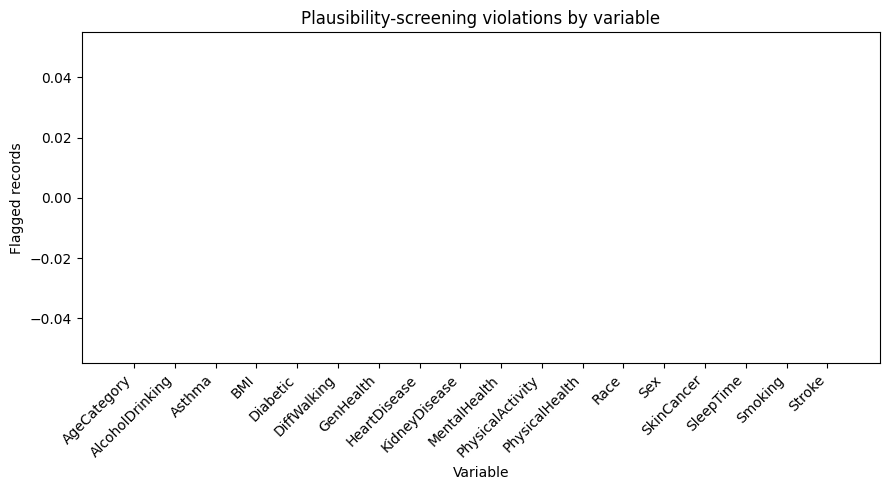

In [6]:

# 4A. Save audit outputs and run explicit plausibility checks
audit.to_csv(OUTPUT_DIR / "dataset_audit.csv")

target_distribution = pd.concat(
    [
        df["Stroke"].value_counts(dropna=False).rename("count"),
        (100 * df["Stroke"].value_counts(normalize=True)).rename("percent"),
    ],
    axis=1,
)
target_distribution.to_csv(
    OUTPUT_DIR / "target_distribution.csv"
)

quality_summary = pd.DataFrame([
    {"check": "records", "value": len(df)},
    {"check": "variables", "value": df.shape[1]},
    {"check": "missing_cells", "value": int(df.isna().sum().sum())},
    {"check": "exact_duplicate_profiles", "value": int(df.duplicated().sum())},
])
display(quality_summary)
quality_summary.to_csv(
    OUTPUT_DIR / "dataset_quality_summary.csv",
    index=False
)

numeric_summary = df[
    ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]
].describe().T
numeric_summary.to_csv(OUTPUT_DIR / "numeric_summary.csv")

rules = {
    "BMI": ("Broad screening range 10–100", df["BMI"].between(10, 100)),
    "PhysicalHealth": ("0–30 days", df["PhysicalHealth"].between(0, 30)),
    "MentalHealth": ("0–30 days", df["MentalHealth"].between(0, 30)),
    "SleepTime": ("1–24 hours", df["SleepTime"].between(1, 24)),
}

plausibility_rows = []
for variable, (rule_text, valid_mask) in rules.items():
    invalid_n = int((~valid_mask).sum())
    plausibility_rows.append({
        "variable": variable,
        "rule": rule_text,
        "invalid_n": invalid_n,
        "invalid_pct": 100 * invalid_n / len(df),
        "decision": "Review only; no automatic deletion",
    })

yes_no_columns = [
    "HeartDisease", "Smoking", "AlcoholDrinking", "Stroke",
    "DiffWalking", "PhysicalActivity", "Asthma",
    "KidneyDisease", "SkinCancer",
]
for variable in yes_no_columns:
    observed = set(df[variable].dropna().astype(str).unique())
    unexpected = sorted(observed - {"Yes", "No"})
    invalid_n = int(df[variable].isin(unexpected).sum()) if unexpected else 0
    plausibility_rows.append({
        "variable": variable,
        "rule": "Expected categories: Yes / No",
        "invalid_n": invalid_n,
        "invalid_pct": 100 * invalid_n / len(df),
        "decision": (
            f"Unexpected categories: {unexpected}"
            if unexpected else
            "No unexpected categories"
        ),
    })

for variable in ["Sex", "AgeCategory", "Race", "Diabetic", "GenHealth"]:
    blank_n = int(
        df[variable].isna().sum()
        + df[variable].astype(str).str.strip().eq("").sum()
    )
    plausibility_rows.append({
        "variable": variable,
        "rule": "Non-missing and non-blank categorical value",
        "invalid_n": blank_n,
        "invalid_pct": 100 * blank_n / len(df),
        "decision": "Review if non-zero",
    })

plausibility_checks = pd.DataFrame(plausibility_rows)
display(plausibility_checks)
plausibility_checks.to_csv(
    OUTPUT_DIR / "plausibility_checks.csv",
    index=False
)

plt.figure(figsize=(9, 5))
plot_df = (
    plausibility_checks.groupby("variable", as_index=False)["invalid_n"]
    .sum()
    .sort_values("invalid_n", ascending=False)
)
plt.bar(plot_df["variable"], plot_df["invalid_n"])
plt.title("Plausibility-screening violations by variable")
plt.xlabel("Variable")
plt.ylabel("Flagged records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


,count,mean,std,min,25%,50%,75%,max
BMI,319795.0,28.325399,6.356100,12.02,24.03,27.34,31.42,94.85
PhysicalHealth,319795.0,3.371710,7.950850,0.00,0.00,0.00,2.00,30.00
MentalHealth,319795.0,3.898366,7.955235,0.00,0.00,0.00,3.00,30.00
SleepTime,319795.0,7.097075,1.436007,1.00,6.00,7.00,8.00,24.00


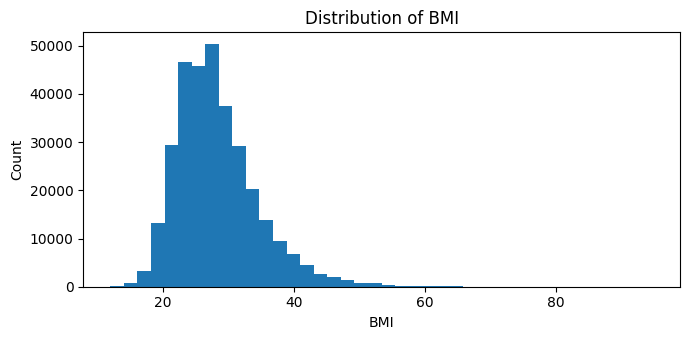

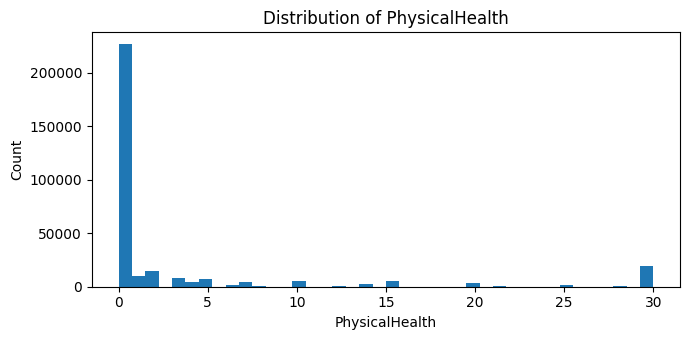

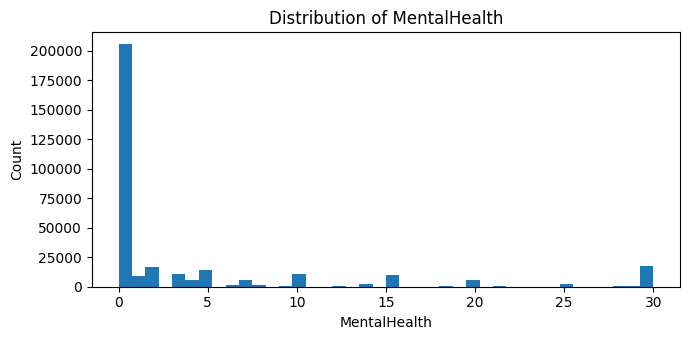

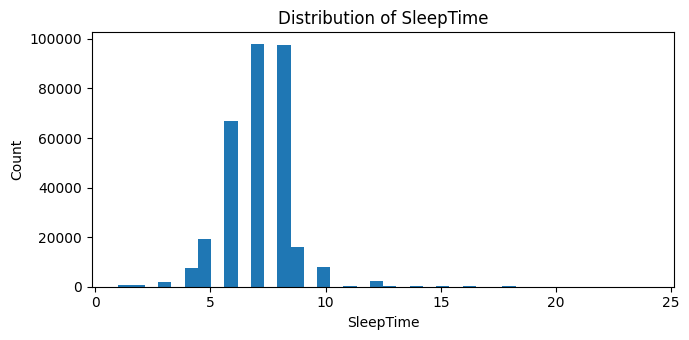

In [7]:
# 5. Basic plausibility review of numeric variables
# No automatic IQR outlier deletion is performed.
expected_numeric = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
numeric_present = [c for c in expected_numeric if c in df.columns]
display(df[numeric_present].describe().T)

for col in numeric_present:
    plt.figure(figsize=(7, 3.5))
    plt.hist(df[col].dropna(), bins=40)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

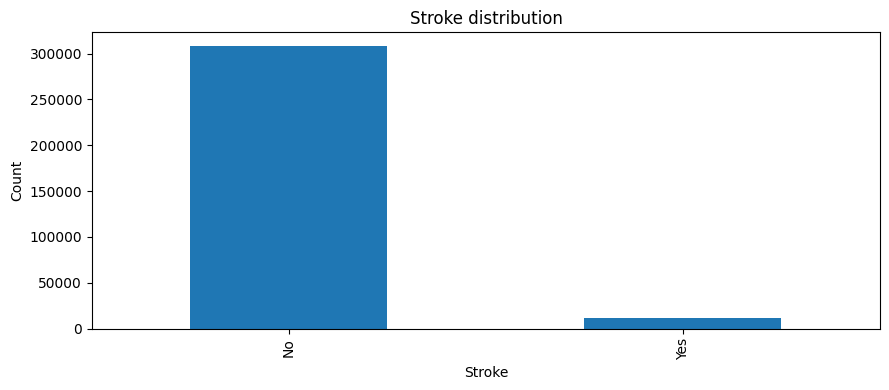

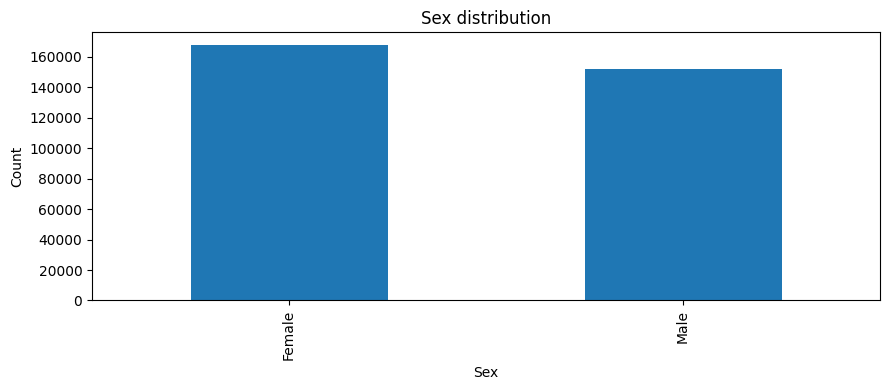

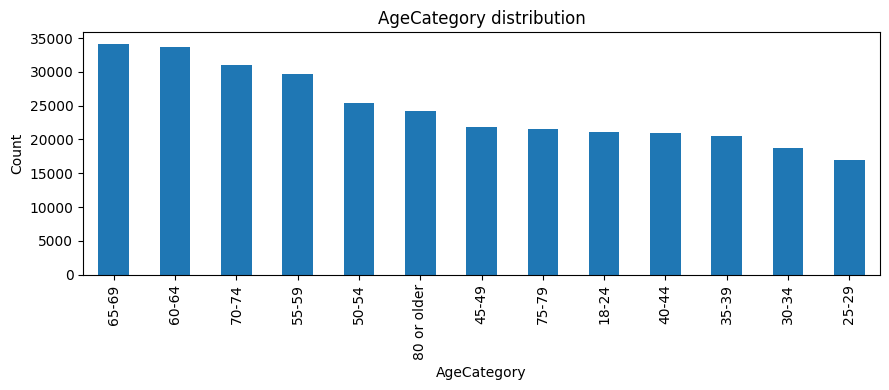

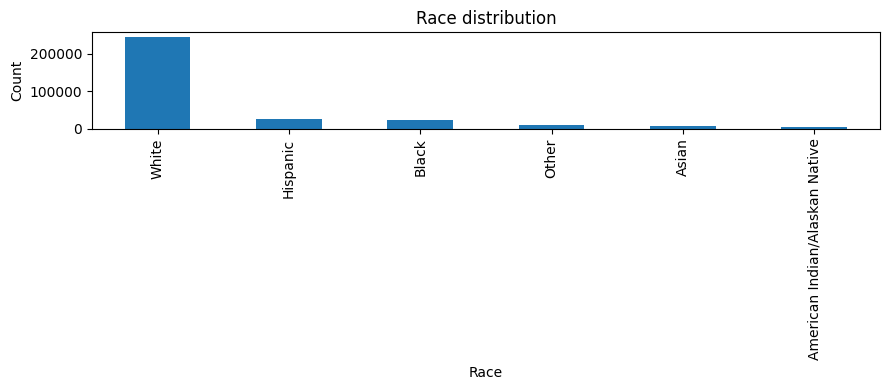


Stroke-status percentages within Sex:


Stroke,No,Yes
Sex,,
Female,96.17,3.83
Male,96.29,3.71



Stroke-status percentages within AgeCategory:


Stroke,No,Yes
AgeCategory,,
18-24,99.71,0.29
25-29,99.47,0.53
30-34,99.30,0.70
35-39,99.06,0.94
40-44,98.61,1.39
45-49,98.04,1.96
50-54,97.30,2.70
55-59,96.30,3.70
60-64,95.60,4.40



Stroke-status percentages within Race:


Stroke,No,Yes
Race,,
American Indian/Alaskan Native,94.10,5.90
Asian,98.13,1.87
Black,94.52,5.48
Hispanic,97.83,2.17
Other,95.64,4.36
White,96.21,3.79


In [8]:
# 6. EDA focused on the UREC1 target and fairness variables
for col in ['Stroke', 'Sex', 'AgeCategory', 'Race']:
    if col in df.columns:
        counts = df[col].value_counts(dropna=False)
        plt.figure(figsize=(9, 4))
        counts.plot(kind='bar')
        plt.title(f'{col} distribution')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

for group_col in ['Sex', 'AgeCategory', 'Race']:
    if group_col in df.columns:
        temp = pd.crosstab(df[group_col], df['Stroke'], normalize='index') * 100
        print(f'\nStroke-status percentages within {group_col}:')
        display(temp.round(2))

In [9]:

# 6A. Persist EDA tables used in the dissertation
for col in ["Stroke", "Sex", "AgeCategory", "Race"]:
    df[col].value_counts(dropna=False).to_csv(
        OUTPUT_DIR / f"distribution_{col}.csv",
        header=["count"]
    )

for group_col in ["Sex", "AgeCategory", "Race"]:
    table = pd.crosstab(
        df[group_col],
        df["Stroke"],
        normalize="index"
    ) * 100
    table.to_csv(
        OUTPUT_DIR / f"stroke_percentages_by_{group_col}.csv"
    )


## Leakage-safe experimental split

The UREC1 states that splitting must occur **before learned preprocessing**. The next cells therefore:

1. define `Stroke` as the target;
2. create an 80% training, 10% validation and 10% locked test split using stratification;
3. fit encoders/scalers **only on training data**;
4. use validation data for model/threshold selection;
5. use the locked test set once for final evaluation.

In [10]:
# 7. Define X/y and create stratified 80/10/10 split
X = df.drop(columns=['Stroke']).copy()
y = df['Stroke'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})
if y.isna().any():
    raise ValueError('Unexpected values found in Stroke. Expected only Yes/No.')

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(X_train), len(X_val), len(X_test)],
    'positive_n': [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    'positive_pct': [100*y_train.mean(), 100*y_val.mean(), 100*y_test.mean()]
})
display(split_summary.round(3))

np.savez(
    OUTPUT_DIR / 'split_indices.npz',
    train_idx=X_train.index.to_numpy(),
    val_idx=X_val.index.to_numpy(),
    test_idx=X_test.index.to_numpy()
)

,split,n,positive_n,positive_pct
0,train,255836,9655,3.774
1,validation,31979,1207,3.774
2,test,31980,1207,3.774


In [11]:

# 7A. Persist split summary for reproducibility
split_summary.to_csv(
    OUTPUT_DIR / "split_summary.csv",
    index=False
)


In [12]:
# 8. Preprocessing definition — fitted inside each pipeline
numeric_features = [c for c in ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime'] if c in X_train.columns]
categorical_features = [c for c in X_train.columns if c not in numeric_features]

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', onehot, categorical_features),
], remainder='drop')

print('Numeric:', numeric_features)
print('Categorical:', categorical_features)

Numeric: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
Categorical: ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [13]:
# 9. Class-imbalance audit
n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
neg_pos_ratio = n_neg / max(n_pos, 1)

print('Training negatives:', n_neg)
print('Training positives:', n_pos)
print('Negative:positive ratio:', round(neg_pos_ratio, 3))
print('No-information accuracy:', round(max(y_train.mean(), 1-y_train.mean()), 4))

Training negatives: 246181
Training positives: 9655
Negative:positive ratio: 25.498
No-information accuracy: 0.9623


In [14]:
# 10. Evaluation helpers
def probability_metrics(y_true, prob, threshold=0.5):
    pred = (np.asarray(prob) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, pred),
        'precision_pos': precision_score(y_true, pred, zero_division=0),
        'recall_pos': recall_score(y_true, pred, zero_division=0),
        'f1_pos': f1_score(y_true, pred, zero_division=0),
        'macro_f1': f1_score(y_true, pred, average='macro', zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'roc_auc': roc_auc_score(y_true, prob),
        'pr_auc': average_precision_score(y_true, prob),
        'brier': brier_score_loss(y_true, prob),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

def choose_threshold(y_true, prob, min_accuracy=0.90):
    thresholds = np.linspace(0.02, 0.98, 193)
    table = pd.DataFrame([probability_metrics(y_true, prob, t) for t in thresholds])
    eligible = table[table['accuracy'] >= min_accuracy].copy()
    if len(eligible):
        best = eligible.sort_values(['f1_pos','balanced_accuracy','recall_pos'], ascending=False).iloc[0]
        constraint_met = True
    else:
        best = table.sort_values(['f1_pos','balanced_accuracy','recall_pos'], ascending=False).iloc[0]
        constraint_met = False
    return float(best['threshold']), table, constraint_met

def get_positive_probability(model, X_data):
    prob = model.predict_proba(X_data)
    return prob[:, 1] if prob.ndim == 2 else prob

## Centralised machine-learning baselines

The UREC1 explicitly names Logistic Regression, Random Forest and gradient-boosted trees. To examine class imbalance, the notebook uses class-aware Logistic Regression and Random Forest plus standard and class-aware XGBoost when XGBoost is available.

In [15]:
# 11. Define centralised model candidates
models = {
    'LogisticRegression_balanced': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
    'RandomForest_balanced': RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_leaf=2,
        class_weight='balanced_subsample', n_jobs=-1, random_state=SEED
    )
}

if XGBOOST_AVAILABLE:
    common_xgb = dict(
        n_estimators=550, max_depth=5, learning_rate=0.05,
        min_child_weight=3, subsample=0.90, colsample_bytree=0.90,
        reg_lambda=2.0, objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', n_jobs=-1, random_state=SEED
    )
    models['XGBoost_standard'] = XGBClassifier(**common_xgb)
    models['XGBoost_class_aware'] = XGBClassifier(**common_xgb, scale_pos_weight=neg_pos_ratio)

model_pipelines = {
    name: Pipeline([('preprocess', clone(preprocessor)), ('model', estimator)])
    for name, estimator in models.items()
}
print('Candidate models:', list(model_pipelines))

Candidate models: ['LogisticRegression_balanced', 'RandomForest_balanced', 'XGBoost_standard', 'XGBoost_class_aware']


In [16]:
# 12. Train centralised models and evaluate on VALIDATION only
trained_models = {}
validation_rows = []
threshold_tables = {}
selected_thresholds = {}

for name, pipeline in model_pipelines.items():
    print('\n' + '='*80)
    print('Training:', name)
    print('='*80)
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    val_prob = get_positive_probability(pipeline, X_val)

    default_metrics = probability_metrics(y_val, val_prob, 0.5)
    default_metrics.update({'model': name, 'evaluation': 'val_default_0.5'})
    validation_rows.append(default_metrics)

    tuned_threshold, threshold_table, constraint_met = choose_threshold(y_val, val_prob, min_accuracy=MIN_VALIDATION_ACCURACY)
    selected_thresholds[name] = tuned_threshold
    threshold_tables[name] = threshold_table

    tuned_metrics = probability_metrics(y_val, val_prob, tuned_threshold)
    tuned_metrics.update({'model': name, 'evaluation': 'val_tuned', 'accuracy_constraint_met': constraint_met})
    validation_rows.append(tuned_metrics)

validation_results = pd.DataFrame(validation_rows)
display(validation_results[[
    'model','evaluation','threshold','accuracy','precision_pos','recall_pos','f1_pos',
    'macro_f1','balanced_accuracy','roc_auc','pr_auc','brier'
]].sort_values(['evaluation','pr_auc'], ascending=[True,False]).round(4))
validation_results.to_csv(OUTPUT_DIR / 'central_validation_metrics.csv', index=False)


Training: LogisticRegression_balanced

Training: RandomForest_balanced

Training: XGBoost_standard

Training: XGBoost_class_aware


,model,evaluation,threshold,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,balanced_accuracy,roc_auc,pr_auc,brier
4,XGBoost_standard,val_default_0.5,0.500,0.9622,0.3846,0.0041,0.0082,0.4945,0.5019,0.8293,0.1717,0.0335
0,LogisticRegression_balanced,val_default_0.5,0.500,0.7556,0.1072,0.7473,0.1875,0.5218,0.7516,0.8274,0.1714,0.1746
6,XGBoost_class_aware,val_default_0.5,0.500,0.7410,0.1021,0.7523,0.1798,0.5130,0.7464,0.8276,0.1700,0.1634
2,RandomForest_balanced,val_default_0.5,0.500,0.9061,0.1442,0.3016,0.1951,0.5726,0.6157,0.7848,0.1191,0.0871
5,XGBoost_standard,val_tuned,0.130,0.9211,0.1984,0.3587,0.2555,0.6069,0.6510,0.8293,0.1717,0.0335
1,LogisticRegression_balanced,val_tuned,0.800,0.9208,0.1987,0.3621,0.2566,0.6074,0.6524,0.8274,0.1714,0.1746
7,XGBoost_class_aware,val_tuned,0.775,0.9200,0.1970,0.3637,0.2556,0.6067,0.6528,0.8276,0.1700,0.1634
3,RandomForest_balanced,val_tuned,0.535,0.9216,0.1498,0.2303,0.1815,0.5702,0.5895,0.7848,0.1191,0.0871


In [17]:
# 13. Select centralised model using VALIDATION data only
# Prefer highest PR-AUC among candidates whose tuned validation accuracy is >=90%.
tuned_val = validation_results[validation_results['evaluation'] == 'val_tuned'].copy()
eligible = tuned_val[tuned_val['accuracy'] >= MIN_VALIDATION_ACCURACY].copy()
if len(eligible):
    best_row = eligible.sort_values(['pr_auc','f1_pos','balanced_accuracy'], ascending=False).iloc[0]
else:
    best_row = tuned_val.sort_values(['pr_auc','f1_pos','balanced_accuracy'], ascending=False).iloc[0]

BEST_CENTRAL_NAME = best_row['model']
BEST_CENTRAL_THRESHOLD = float(selected_thresholds[BEST_CENTRAL_NAME])
best_central_model = trained_models[BEST_CENTRAL_NAME]

print('Selected central model:', BEST_CENTRAL_NAME)
print('Selected validation threshold:', round(BEST_CENTRAL_THRESHOLD, 4))
print('Validation accuracy:', round(float(best_row['accuracy']), 4))
print('Validation PR-AUC:', round(float(best_row['pr_auc']), 4))
print('Validation positive F1:', round(float(best_row['f1_pos']), 4))

Selected central model: XGBoost_standard
Selected validation threshold: 0.13
Validation accuracy: 0.9211
Validation PR-AUC: 0.1717
Validation positive F1: 0.2555


In [18]:
# 14. Final LOCKED TEST evaluation of all centralised models
central_test_rows = []
central_test_probs = {}
for name, model in trained_models.items():
    prob = get_positive_probability(model, X_test)
    central_test_probs[name] = prob
    row = probability_metrics(y_test, prob, selected_thresholds[name])
    row.update({'model': name, 'evaluation': 'locked_test'})
    central_test_rows.append(row)

central_test_results = pd.DataFrame(central_test_rows)
display(central_test_results[[
    'model','threshold','accuracy','precision_pos','recall_pos','f1_pos','macro_f1',
    'balanced_accuracy','roc_auc','pr_auc','brier'
]].sort_values('pr_auc', ascending=False).round(4))
central_test_results.to_csv(OUTPUT_DIR / 'central_locked_test_metrics.csv', index=False)

best_test_row = central_test_results[central_test_results['model'] == BEST_CENTRAL_NAME].iloc[0]
if best_test_row['accuracy'] >= 0.90:
    print(f" Selected central model achieved {best_test_row['accuracy']:.2%} locked-test accuracy.")
else:
    print(f" Selected central model achieved {best_test_row['accuracy']:.2%} locked-test accuracy. Do NOT retune using the test set.")

,model,threshold,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,balanced_accuracy,roc_auc,pr_auc,brier
2,XGBoost_standard,0.130,0.9201,0.1892,0.3397,0.2430,0.6004,0.6413,0.8245,0.1695,0.0336
3,XGBoost_class_aware,0.775,0.9191,0.1846,0.3347,0.2379,0.5976,0.6384,0.8207,0.1679,0.1607
0,LogisticRegression_balanced,0.800,0.9195,0.1860,0.3355,0.2394,0.5984,0.6390,0.8227,0.1638,0.1720
1,RandomForest_balanced,0.535,0.9234,0.1502,0.2212,0.1789,0.5693,0.5861,0.7876,0.1195,0.0853


 Selected central model achieved 92.01% locked-test accuracy.


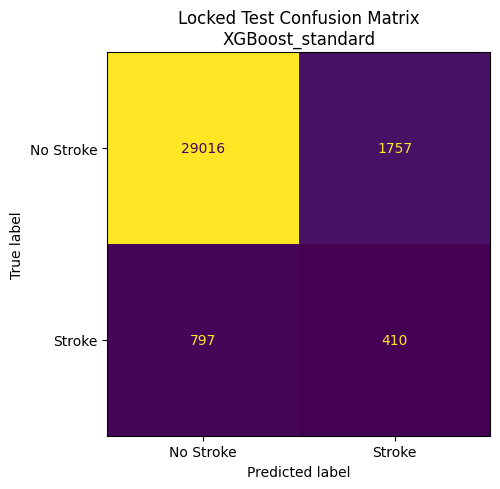

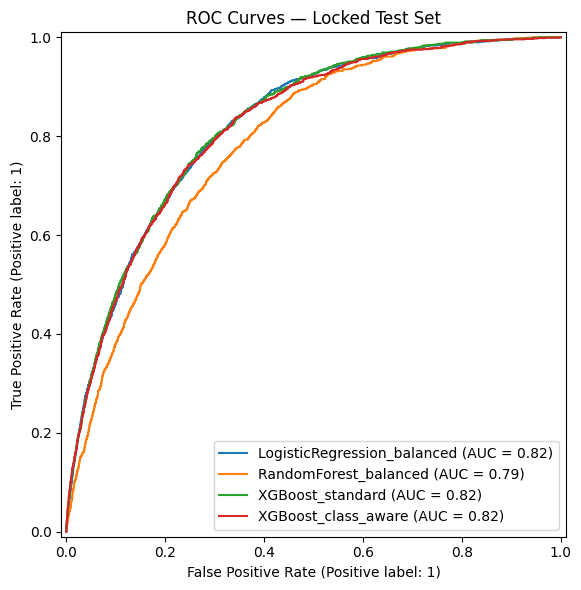

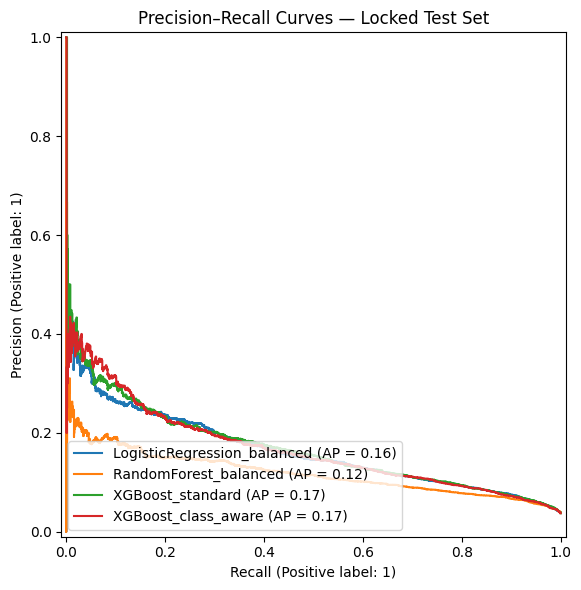

In [19]:
# 15. Confusion matrix + ROC/PR curves for centralised models
best_prob = central_test_probs[BEST_CENTRAL_NAME]
best_pred = (best_prob >= BEST_CENTRAL_THRESHOLD).astype(int)

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=['No Stroke','Stroke'], ax=ax, colorbar=False)
ax.set_title(f'Locked Test Confusion Matrix\n{BEST_CENTRAL_NAME}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'best_central_confusion_matrix.png', dpi=160)
plt.show()

plt.figure(figsize=(7,6)); ax=plt.gca()
for name, prob in central_test_probs.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)
plt.title('ROC Curves — Locked Test Set'); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'central_roc_curves.png', dpi=160); plt.show()

plt.figure(figsize=(7,6)); ax=plt.gca()
for name, prob in central_test_probs.items():
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=ax)
plt.title('Precision–Recall Curves — Locked Test Set'); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'central_pr_curves.png', dpi=160); plt.show()

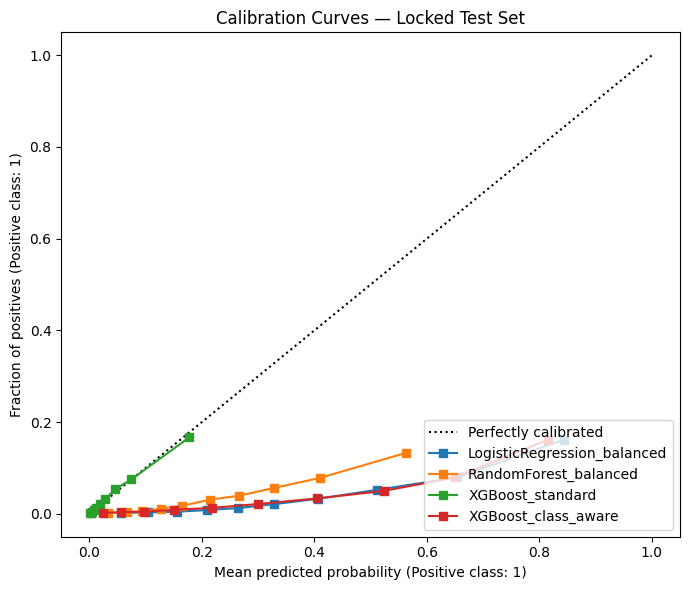

Brier score: lower is better.


,model,brier
2,XGBoost_standard,0.03364
1,RandomForest_balanced,0.08528
3,XGBoost_class_aware,0.16072
0,LogisticRegression_balanced,0.17196


In [20]:
# 16. Calibration assessment for centralised models
plt.figure(figsize=(7,6)); ax=plt.gca()
for name, prob in central_test_probs.items():
    CalibrationDisplay.from_predictions(y_test, prob, n_bins=10, strategy='quantile', name=name, ax=ax)
plt.title('Calibration Curves — Locked Test Set'); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'central_calibration_curves.png', dpi=160); plt.show()

print('Brier score: lower is better.')
display(central_test_results[['model','brier']].sort_values('brier').round(5))

# Centralised neural-network baseline and federated-learning simulation

The UREC1 specifies a neural-network classifier for the simulated federated experiment if technically feasible. To make the centralised-vs-federated comparison fair, the same MLP architecture and the same training-only preprocessing are used for a centralised neural network and a federated neural network trained across artificial non-IID clients using FedAvg.

In [21]:
# 17. PyTorch setup
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)

PyTorch: 2.10.0+cpu
Device: cpu


In [22]:
# 18. Dense preprocessing for neural networks — fitted only on X_train
try:
    nn_onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    nn_onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

nn_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', nn_onehot, categorical_features),
], remainder='drop')

X_train_nn = nn_preprocessor.fit_transform(X_train).astype(np.float32)
X_val_nn = nn_preprocessor.transform(X_val).astype(np.float32)
X_test_nn = nn_preprocessor.transform(X_test).astype(np.float32)
y_train_nn = y_train.to_numpy(dtype=np.float32)
y_val_nn = y_val.to_numpy(dtype=np.float32)
y_test_nn = y_test.to_numpy(dtype=np.float32)

print('NN train shape:', X_train_nn.shape)
print('NN validation shape:', X_val_nn.shape)
print('NN test shape:', X_test_nn.shape)
joblib.dump(nn_preprocessor, OUTPUT_DIR / 'nn_preprocessor.joblib')

NN train shape: (255836, 50)
NN validation shape: (31979, 50)
NN test shape: (31980, 50)


['/kaggle/working/urec1_outputs/nn_preprocessor.joblib']

In [23]:
# 19. Neural-network model and helpers
class StrokeMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

def predict_nn(model, X_array, batch_size=4096):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X_array)), batch_size=batch_size, shuffle=False)
    probs=[]
    with torch.no_grad():
        for (xb,) in loader:
            probs.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
    return np.concatenate(probs)

GLOBAL_POS_WEIGHT = float((len(y_train_nn) - y_train_nn.sum()) / max(y_train_nn.sum(), 1.0))
print('Global NN positive-class weight:', round(GLOBAL_POS_WEIGHT,3))

Global NN positive-class weight: 25.498


In [24]:
# 20. Train centralised neural-network baseline
def train_central_nn(X_train_arr, y_train_arr, X_val_arr, y_val_arr, epochs=6, batch_size=2048, lr=1e-3):
    model = StrokeMLP(X_train_arr.shape[1]).to(DEVICE)
    train_ds = TensorDataset(torch.from_numpy(X_train_arr), torch.from_numpy(y_train_arr))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(GLOBAL_POS_WEIGHT, device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_state=None; best_pr_auc=-np.inf; history=[]
    for epoch in range(1, epochs+1):
        model.train(); running_loss=0.0
        for xb,yb in train_loader:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE)
            optimizer.zero_grad(); logits=model(xb); loss=criterion(logits,yb)
            loss.backward(); optimizer.step(); running_loss += loss.item()*len(xb)
        val_prob=predict_nn(model, X_val_arr)
        val_pr_auc=average_precision_score(y_val_arr,val_prob)
        val_roc_auc=roc_auc_score(y_val_arr,val_prob)
        history.append({'epoch':epoch,'train_loss':running_loss/len(train_ds),'val_pr_auc':val_pr_auc,'val_roc_auc':val_roc_auc})
        print(f'Epoch {epoch:02d} | loss={history[-1]["train_loss"]:.4f} | val PR-AUC={val_pr_auc:.4f} | val ROC-AUC={val_roc_auc:.4f}')
        if val_pr_auc > best_pr_auc:
            best_pr_auc=val_pr_auc
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

central_nn, central_nn_history = train_central_nn(X_train_nn,y_train_nn,X_val_nn,y_val_nn)
central_nn_history.to_csv(OUTPUT_DIR / 'central_nn_history.csv', index=False)
torch.save(central_nn.state_dict(), OUTPUT_DIR / 'central_nn_state.pt')

Epoch 01 | loss=1.1023 | val PR-AUC=0.1710 | val ROC-AUC=0.8271
Epoch 02 | loss=1.0032 | val PR-AUC=0.1751 | val ROC-AUC=0.8289
Epoch 03 | loss=0.9932 | val PR-AUC=0.1785 | val ROC-AUC=0.8295
Epoch 04 | loss=0.9888 | val PR-AUC=0.1802 | val ROC-AUC=0.8299
Epoch 05 | loss=0.9852 | val PR-AUC=0.1801 | val ROC-AUC=0.8308
Epoch 06 | loss=0.9828 | val PR-AUC=0.1805 | val ROC-AUC=0.8307


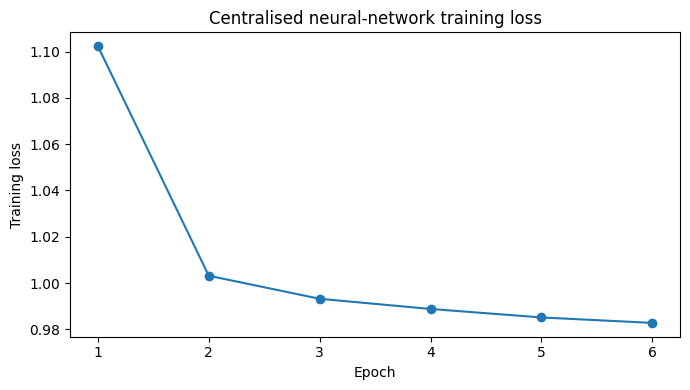

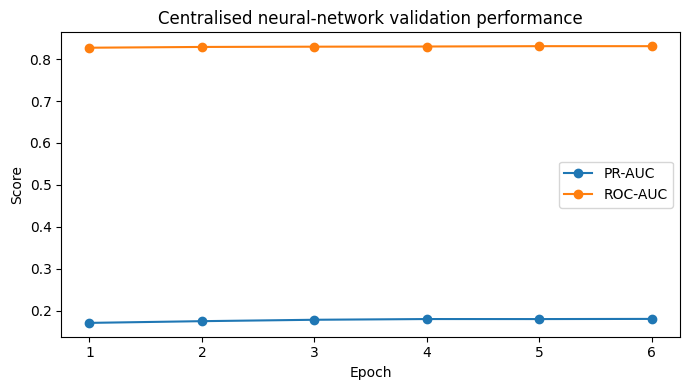

In [25]:

# 20A. Centralised NN training-history charts
plt.figure(figsize=(7, 4))
plt.plot(
    central_nn_history["epoch"],
    central_nn_history["train_loss"],
    marker="o"
)
plt.title("Centralised neural-network training loss")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    central_nn_history["epoch"],
    central_nn_history["val_pr_auc"],
    marker="o",
    label="PR-AUC"
)
plt.plot(
    central_nn_history["epoch"],
    central_nn_history["val_roc_auc"],
    marker="o",
    label="ROC-AUC"
)
plt.title("Centralised neural-network validation performance")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
# 21. Select central-NN threshold on validation only
central_nn_val_prob = predict_nn(central_nn, X_val_nn)
CENTRAL_NN_THRESHOLD, central_nn_threshold_table, central_nn_constraint = choose_threshold(y_val_nn, central_nn_val_prob, MIN_VALIDATION_ACCURACY)
central_nn_test_prob = predict_nn(central_nn, X_test_nn)
central_nn_test_metrics = probability_metrics(y_test_nn, central_nn_test_prob, CENTRAL_NN_THRESHOLD)
print('Central NN threshold:', round(CENTRAL_NN_THRESHOLD,4))
display(pd.DataFrame([central_nn_test_metrics]).round(4))

Central NN threshold: 0.78


,threshold,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,balanced_accuracy,roc_auc,pr_auc,brier,tn,fp,fn,tp
0,0.78,0.9224,0.1954,0.3389,0.2479,0.6035,0.6421,0.8269,0.1771,0.173,29089,1684,798,409


## Controlled non-IID client construction

A Dirichlet allocation creates artificial clients with different stroke/no-stroke proportions. This is a simulation of statistical heterogeneity only; the clients do **not** represent real hospitals, organisations or identifiable individuals.

In [27]:
# 22. Create non-IID federated clients using Dirichlet partitioning
def dirichlet_partition(labels, n_clients=5, alpha=0.5, seed=42):
    rng=np.random.default_rng(seed)
    labels=np.asarray(labels).astype(int)
    client_indices=[[] for _ in range(n_clients)]
    for cls in np.unique(labels):
        cls_idx=np.where(labels==cls)[0]
        rng.shuffle(cls_idx)
        proportions=rng.dirichlet(np.repeat(alpha,n_clients))
        split_points=(np.cumsum(proportions)[:-1]*len(cls_idx)).astype(int)
        splits=np.split(cls_idx, split_points)
        for cid, split in enumerate(splits):
            client_indices[cid].extend(split.tolist())
    for cid in range(n_clients):
        rng.shuffle(client_indices[cid])
        client_indices[cid]=np.array(client_indices[cid],dtype=int)
    return client_indices

N_CLIENTS=5
DIRICHLET_ALPHA=0.5
client_indices=dirichlet_partition(y_train_nn,N_CLIENTS,DIRICHLET_ALPHA,SEED)
client_summary=[]
for cid,idx in enumerate(client_indices):
    local_y=y_train_nn[idx]
    client_summary.append({'client':cid+1,'n':len(idx),'stroke_n':int(local_y.sum()),'stroke_pct':100*float(local_y.mean()) if len(idx) else np.nan})
client_summary=pd.DataFrame(client_summary)
display(client_summary.round(3))
client_summary.to_csv(OUTPUT_DIR / 'federated_client_distribution.csv', index=False)

,client,n,stroke_n,stroke_pct
0,1,12656,1516,11.979
1,2,3998,2401,60.055
2,3,5266,3789,71.952
3,4,99144,828,0.835
4,5,134772,1121,0.832


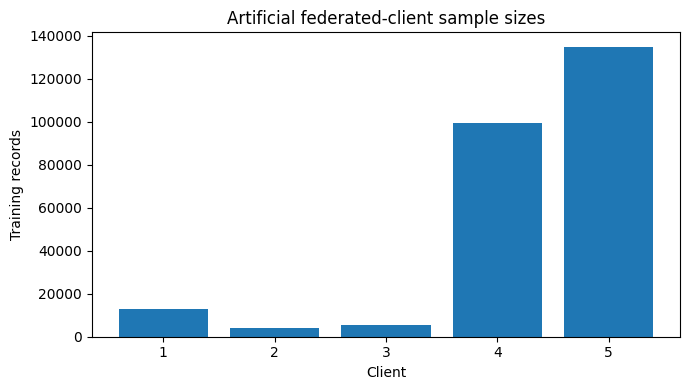

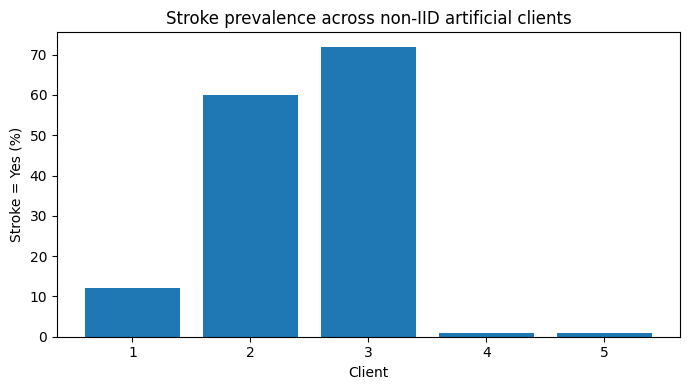

In [28]:

# 22A. Non-IID client-distribution charts
plt.figure(figsize=(7, 4))
plt.bar(
    client_summary["client"].astype(str),
    client_summary["n"]
)
plt.title("Artificial federated-client sample sizes")
plt.xlabel("Client")
plt.ylabel("Training records")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(
    client_summary["client"].astype(str),
    client_summary["stroke_pct"]
)
plt.title("Stroke prevalence across non-IID artificial clients")
plt.xlabel("Client")
plt.ylabel("Stroke = Yes (%)")
plt.tight_layout()
plt.show()


In [29]:
# 23. FedAvg helpers
def train_local_model(global_state, X_local, y_local, input_dim, local_epochs=1, batch_size=2048, lr=1e-3):
    model=StrokeMLP(input_dim).to(DEVICE)
    model.load_state_dict(global_state)
    ds=TensorDataset(torch.from_numpy(X_local), torch.from_numpy(y_local))
    loader=DataLoader(ds,batch_size=batch_size,shuffle=True)
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor(GLOBAL_POS_WEIGHT,device=DEVICE))
    optimizer=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)
    model.train()
    for _ in range(local_epochs):
        for xb,yb in loader:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE)
            optimizer.zero_grad(); loss=criterion(model(xb),yb); loss.backward(); optimizer.step()
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

def fedavg(state_dicts, weights):
    total=float(np.sum(weights)); averaged={}
    for key in state_dicts[0].keys():
        averaged[key]=sum(state[key]*(weight/total) for state,weight in zip(state_dicts,weights))
    return averaged

In [30]:
# 24. Federated training with FedAvg
FED_ROUNDS=6
LOCAL_EPOCHS=1
LOCAL_LR=1e-3
federated_model=StrokeMLP(X_train_nn.shape[1]).to(DEVICE)
best_fed_state=None; best_fed_pr_auc=-np.inf; fed_history=[]

for round_id in range(1,FED_ROUNDS+1):
    global_state={k:v.detach().cpu().clone() for k,v in federated_model.state_dict().items()}
    local_states=[]; local_sizes=[]
    for client_id,idx in enumerate(client_indices):
        if len(idx)==0: continue
        state=train_local_model(global_state,X_train_nn[idx],y_train_nn[idx],X_train_nn.shape[1],LOCAL_EPOCHS,2048,LOCAL_LR)
        local_states.append(state); local_sizes.append(len(idx))
    federated_model.load_state_dict(fedavg(local_states,local_sizes))
    val_prob=predict_nn(federated_model,X_val_nn)
    val_pr_auc=average_precision_score(y_val_nn,val_prob)
    val_roc_auc=roc_auc_score(y_val_nn,val_prob)
    fed_history.append({'round':round_id,'val_pr_auc':val_pr_auc,'val_roc_auc':val_roc_auc})
    print(f'Round {round_id:02d} | val PR-AUC={val_pr_auc:.4f} | val ROC-AUC={val_roc_auc:.4f}')
    if val_pr_auc>best_fed_pr_auc:
        best_fed_pr_auc=val_pr_auc
        best_fed_state={k:v.detach().cpu().clone() for k,v in federated_model.state_dict().items()}

federated_model.load_state_dict(best_fed_state)
fed_history=pd.DataFrame(fed_history)
fed_history.to_csv(OUTPUT_DIR / 'federated_history.csv', index=False)
torch.save(federated_model.state_dict(), OUTPUT_DIR / 'federated_nn_state.pt')

Round 01 | val PR-AUC=0.1415 | val ROC-AUC=0.7961
Round 02 | val PR-AUC=0.1553 | val ROC-AUC=0.8148
Round 03 | val PR-AUC=0.1664 | val ROC-AUC=0.8231
Round 04 | val PR-AUC=0.1699 | val ROC-AUC=0.8252
Round 05 | val PR-AUC=0.1711 | val ROC-AUC=0.8263
Round 06 | val PR-AUC=0.1729 | val ROC-AUC=0.8264


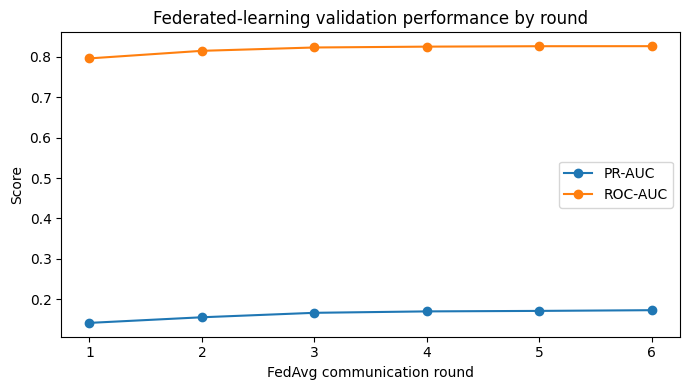

In [31]:

# 24A. Federated validation-history chart
plt.figure(figsize=(7, 4))
plt.plot(
    fed_history["round"],
    fed_history["val_pr_auc"],
    marker="o",
    label="PR-AUC"
)
plt.plot(
    fed_history["round"],
    fed_history["val_roc_auc"],
    marker="o",
    label="ROC-AUC"
)
plt.title("Federated-learning validation performance by round")
plt.xlabel("FedAvg communication round")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
# 25. Federated threshold selection on validation, then locked test
fed_val_prob=predict_nn(federated_model,X_val_nn)
FED_THRESHOLD, fed_threshold_table, fed_constraint=choose_threshold(y_val_nn,fed_val_prob,MIN_VALIDATION_ACCURACY)
fed_test_prob=predict_nn(federated_model,X_test_nn)
fed_test_metrics=probability_metrics(y_test_nn,fed_test_prob,FED_THRESHOLD)
print('Federated threshold:', round(FED_THRESHOLD,4))
display(pd.DataFrame([fed_test_metrics]).round(4))

Federated threshold: 0.515


,threshold,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,balanced_accuracy,roc_auc,pr_auc,brier,tn,fp,fn,tp
0,0.515,0.9248,0.1957,0.319,0.2426,0.6015,0.6338,0.8214,0.1675,0.0628,29191,1582,822,385


In [33]:
# 26. Centralised vs federated comparison on the SAME locked test set
nn_comparison=pd.DataFrame([
    {'model':'Centralised_NN', **central_nn_test_metrics},
    {'model':'Federated_NN_nonIID_FedAvg', **fed_test_metrics}
])
display(nn_comparison[[
    'model','threshold','accuracy','precision_pos','recall_pos','f1_pos','macro_f1',
    'balanced_accuracy','roc_auc','pr_auc','brier'
]].round(4))
nn_comparison.to_csv(OUTPUT_DIR / 'central_vs_federated_nn.csv', index=False)

,model,threshold,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,balanced_accuracy,roc_auc,pr_auc,brier
0,Centralised_NN,0.780,0.9224,0.1954,0.3389,0.2479,0.6035,0.6421,0.8269,0.1771,0.1730
1,Federated_NN_nonIID_FedAvg,0.515,0.9248,0.1957,0.3190,0.2426,0.6015,0.6338,0.8214,0.1675,0.0628


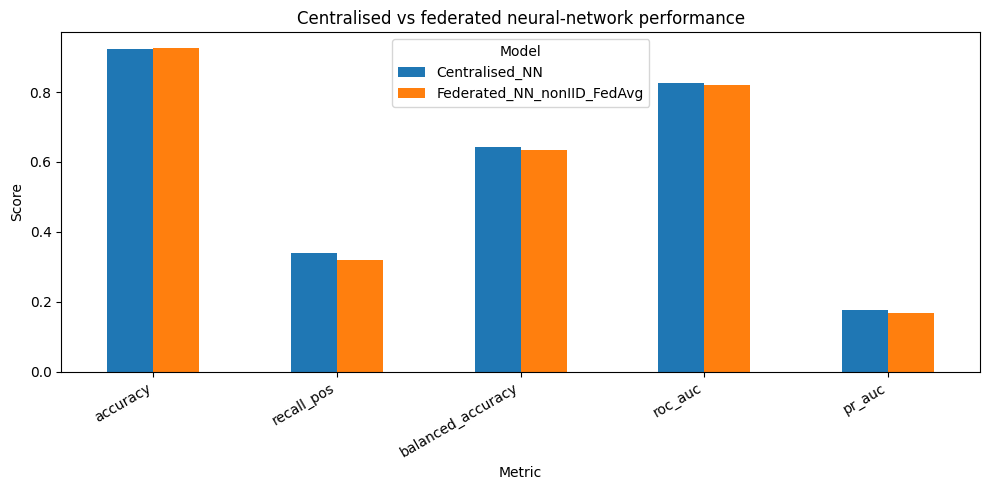

In [34]:

# 26A. Centralised-vs-federated neural-network comparison chart
comparison_metrics = [
    "accuracy",
    "recall_pos",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc",
]
comparison_plot = (
    nn_comparison
    .set_index("model")[comparison_metrics]
    .T
)

ax = comparison_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Centralised vs federated neural-network performance")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


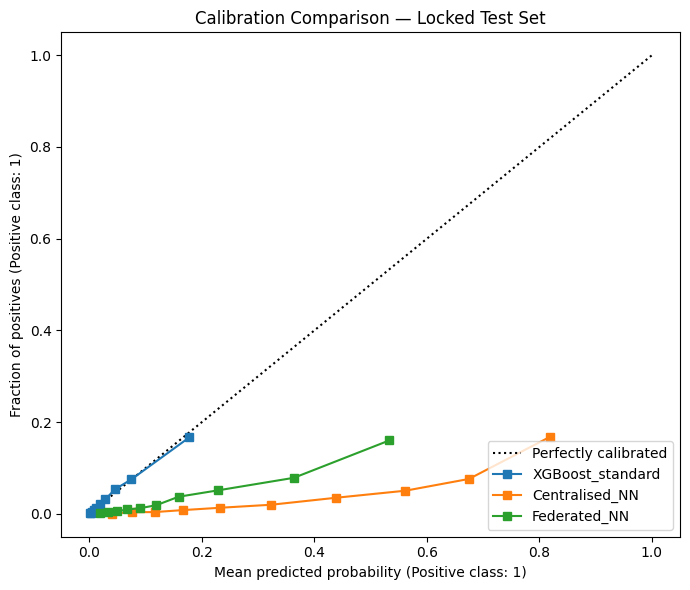

In [35]:
# 27. Calibration comparison: best central ML vs central NN vs federated NN
best_central_test_prob=central_test_probs[BEST_CENTRAL_NAME]
plt.figure(figsize=(7,6)); ax=plt.gca()
CalibrationDisplay.from_predictions(y_test,best_central_test_prob,n_bins=10,strategy='quantile',name=BEST_CENTRAL_NAME,ax=ax)
CalibrationDisplay.from_predictions(y_test_nn,central_nn_test_prob,n_bins=10,strategy='quantile',name='Centralised_NN',ax=ax)
CalibrationDisplay.from_predictions(y_test_nn,fed_test_prob,n_bins=10,strategy='quantile',name='Federated_NN',ax=ax)
plt.title('Calibration Comparison — Locked Test Set'); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calibration_central_vs_federated.png', dpi=160); plt.show()


## Centralised and federated neural-network confusion matrices

These separate locked-test matrices close the remaining UREC1 evaluation gap and make the minority-class false-negative/false-positive trade-off directly visible.


,Pred_No_Stroke,Pred_Stroke
Actual_No_Stroke,29089,1684
Actual_Stroke,798,409


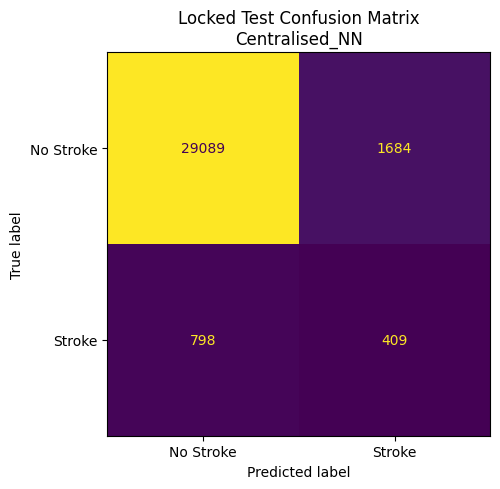

,Pred_No_Stroke,Pred_Stroke
Actual_No_Stroke,29191,1582
Actual_Stroke,822,385


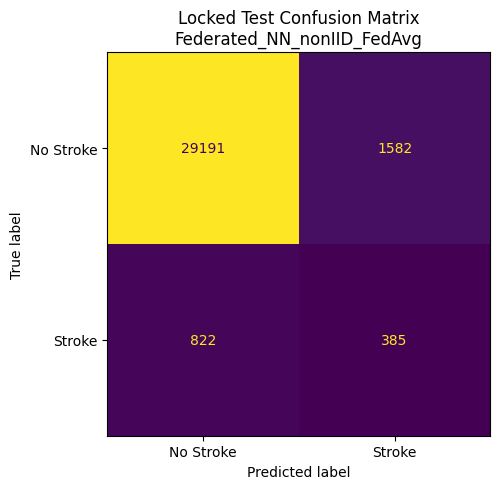

In [36]:

# 27A. Locked-test confusion matrices for both neural-network experiments
nn_confusion_specs = [
    (
        "Centralised_NN",
        y_test_nn,
        central_nn_test_prob,
        CENTRAL_NN_THRESHOLD
    ),
    (
        "Federated_NN_nonIID_FedAvg",
        y_test_nn,
        fed_test_prob,
        FED_THRESHOLD
    ),
]

for model_name, y_true_values, probabilities, threshold in nn_confusion_specs:
    y_true_values = np.asarray(y_true_values).astype(int)
    predictions = (
        np.asarray(probabilities) >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_true_values,
        predictions,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm,
        index=["Actual_No_Stroke", "Actual_Stroke"],
        columns=["Pred_No_Stroke", "Pred_Stroke"]
    )
    display(cm_df)
    cm_df.to_csv(
        OUTPUT_DIR / f"confusion_matrix_{model_name}.csv"
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Stroke", "Stroke"]
    ).plot(ax=ax, colorbar=False)

    ax.set_title(
        f"Locked Test Confusion Matrix\n{model_name}"
    )
    plt.tight_layout()
    plt.show()


# Subgroup performance and fairness audit

The UREC1 proposes subgroup assessment across `Sex`, `AgeCategory` and `Race` where sample sizes permit. This section reports subgroup sample size, prevalence, accuracy, positive-class recall/precision/F1, false-positive rate, ROC-AUC, PR-AUC and Brier score.

These results identify **performance differences**. They should not be interpreted as proving that a model is globally “fair” or “unfair”.

In [37]:
# 28. Fairness/subgroup metric helper
def subgroup_metrics(raw_X,y_true,prob,threshold,group_col,model_name,min_n=200):
    data=pd.DataFrame({'group':raw_X[group_col].astype(str).to_numpy(),'y':np.asarray(y_true).astype(int),'prob':np.asarray(prob)})
    rows=[]
    for group_value,g in data.groupby('group',dropna=False):
        if len(g)<min_n: continue
        pred=(g['prob'].to_numpy()>=threshold).astype(int)
        y_g=g['y'].to_numpy(); p_g=g['prob'].to_numpy()
        tn,fp,fn,tp=confusion_matrix(y_g,pred,labels=[0,1]).ravel()
        fpr=fp/(fp+tn) if (fp+tn) else np.nan
        roc=roc_auc_score(y_g,p_g) if len(np.unique(y_g))==2 else np.nan
        pr=average_precision_score(y_g,p_g) if y_g.sum()>0 else np.nan
        rows.append({
            'model':model_name,'attribute':group_col,'group':group_value,'n':len(g),
            'stroke_n':int(y_g.sum()),'stroke_prevalence':float(y_g.mean()),
            'accuracy':accuracy_score(y_g,pred),
            'precision_pos':precision_score(y_g,pred,zero_division=0),
            'recall_pos':recall_score(y_g,pred,zero_division=0),
            'f1_pos':f1_score(y_g,pred,zero_division=0),
            'false_positive_rate':fpr,'roc_auc':roc,'pr_auc':pr,'brier':brier_score_loss(y_g,p_g)
        })
    return pd.DataFrame(rows)

In [38]:
# 29. Run subgroup analysis for best central model AND federated model
fairness_tables=[]
for group_col in ['Sex','AgeCategory','Race']:
    if group_col not in X_test.columns: continue
    fairness_tables.append(subgroup_metrics(X_test,y_test,best_central_test_prob,BEST_CENTRAL_THRESHOLD,group_col,BEST_CENTRAL_NAME,200))
    fairness_tables.append(subgroup_metrics(X_test,y_test_nn,fed_test_prob,FED_THRESHOLD,group_col,'Federated_NN_nonIID_FedAvg',200))

fairness_results=pd.concat(fairness_tables,ignore_index=True)
display(fairness_results.sort_values(['attribute','model','group']).round(4))
fairness_results.to_csv(OUTPUT_DIR / 'subgroup_fairness_metrics.csv', index=False)

,model,attribute,group,n,stroke_n,stroke_prevalence,accuracy,precision_pos,recall_pos,f1_pos,false_positive_rate,roc_auc,pr_auc,brier
17,Federated_NN_nonIID_FedAvg,AgeCategory,18-24,2216,8,0.0036,0.9964,0.0000,0.0000,0.0000,0.0000,0.8215,0.0560,0.0043
18,Federated_NN_nonIID_FedAvg,AgeCategory,25-29,1683,10,0.0059,0.9935,0.0000,0.0000,0.0000,0.0006,0.8183,0.1534,0.0080
19,Federated_NN_nonIID_FedAvg,AgeCategory,30-34,1845,11,0.0060,0.9935,0.0000,0.0000,0.0000,0.0005,0.8357,0.0741,0.0079
20,Federated_NN_nonIID_FedAvg,AgeCategory,35-39,2130,15,0.0070,0.9934,0.6667,0.1333,0.2222,0.0005,0.7101,0.1474,0.0109
21,Federated_NN_nonIID_FedAvg,AgeCategory,40-44,2054,24,0.0117,0.9859,0.2222,0.0833,0.1212,0.0034,0.7735,0.0944,0.0191
22,Federated_NN_nonIID_FedAvg,AgeCategory,45-49,2199,42,0.0191,0.9723,0.1724,0.1190,0.1408,0.0111,0.8344,0.1368,0.0286
23,Federated_NN_nonIID_FedAvg,AgeCategory,50-54,2486,69,0.0278,0.9574,0.2154,0.2029,0.2090,0.0211,0.7876,0.1952,0.0423
24,Federated_NN_nonIID_FedAvg,AgeCategory,55-59,3007,113,0.0376,0.9408,0.2556,0.3009,0.2764,0.0342,0.8152,0.1724,0.0580
25,Federated_NN_nonIID_FedAvg,AgeCategory,60-64,3377,147,0.0435,0.9195,0.2294,0.3605,0.2804,0.0551,0.7819,0.2201,0.0750
26,Federated_NN_nonIID_FedAvg,AgeCategory,65-69,3375,181,0.0536,0.9090,0.2237,0.2818,0.2494,0.0554,0.7512,0.1969,0.0883


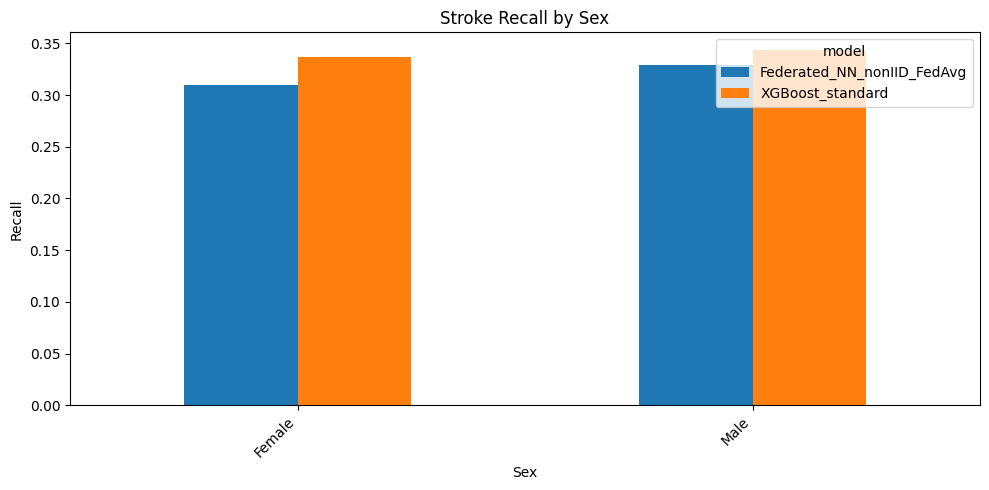

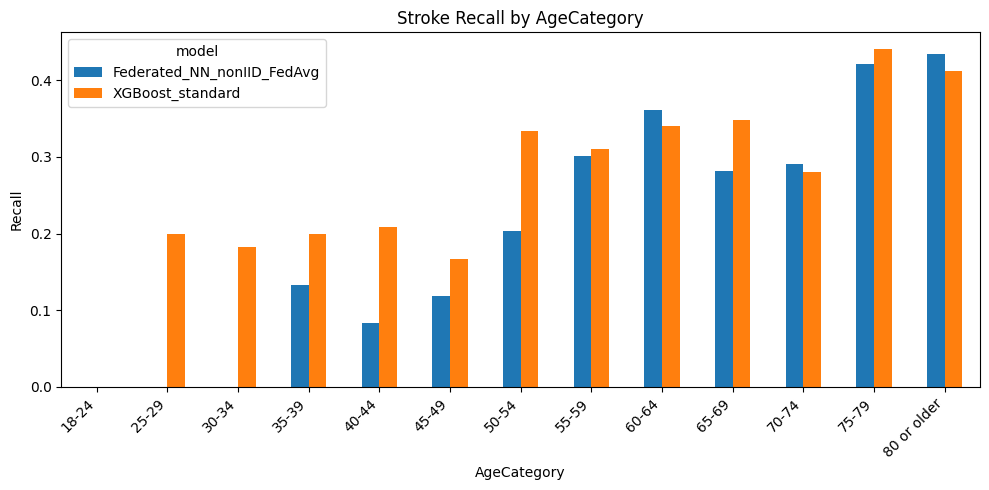

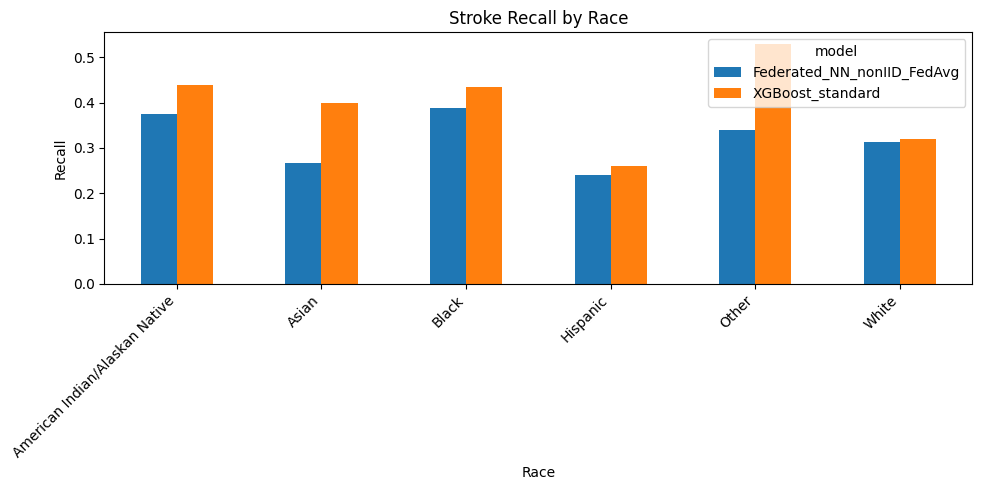

In [39]:
# 30. Visualise subgroup recall
for attribute in fairness_results['attribute'].unique():
    plot_df=fairness_results[fairness_results['attribute']==attribute].copy()
    pivot=plot_df.pivot(index='group',columns='model',values='recall_pos')
    ax=pivot.plot(kind='bar',figsize=(10,5))
    ax.set_title(f'Stroke Recall by {attribute}')
    ax.set_ylabel('Recall'); ax.set_xlabel(attribute)
    plt.xticks(rotation=45,ha='right'); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'subgroup_recall_{attribute}.png', dpi=160)
    plt.show()

# SHAP explainability

SHAP is applied to the selected centralised model. The explanation is explicitly treated as a description of **model behaviour**, not evidence that a feature causes stroke.

SHAP: 0.51.0
Explaining: XGBoost_standard | estimator: XGBClassifier


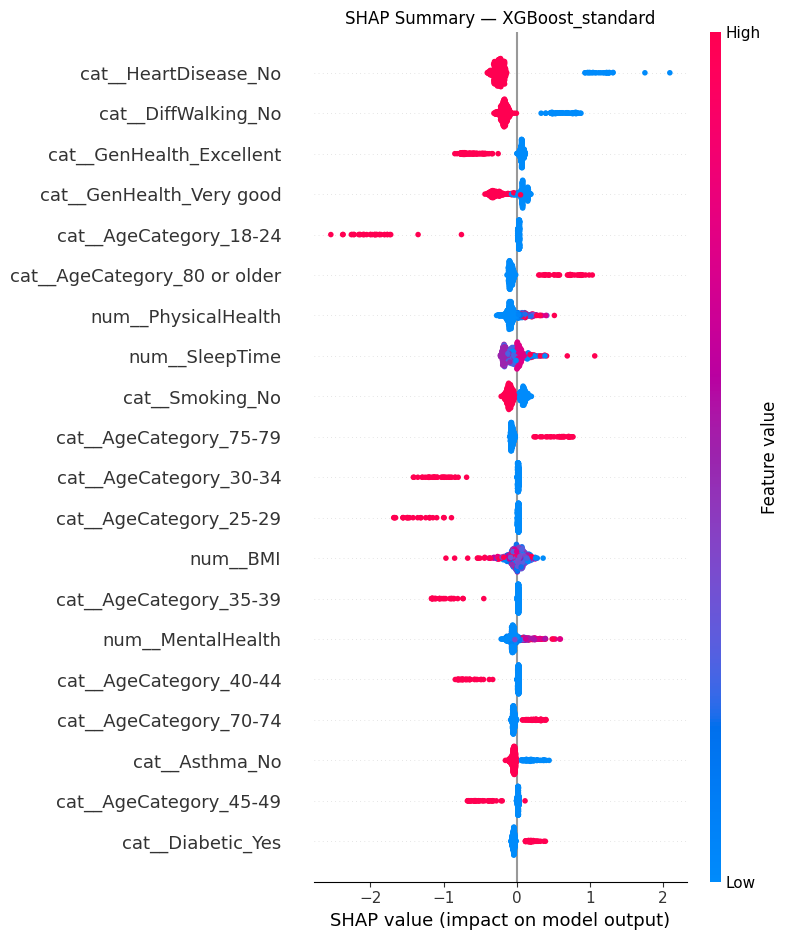

,feature,mean_abs_shap
4,cat__HeartDisease_No,0.289669
10,cat__DiffWalking_No,0.215702
39,cat__GenHealth_Excellent,0.189966
43,cat__GenHealth_Very good,0.173113
14,cat__AgeCategory_18-24,0.158648
26,cat__AgeCategory_80 or older,0.125174
1,num__PhysicalHealth,0.099055
3,num__SleepTime,0.097499
6,cat__Smoking_No,0.097106
25,cat__AgeCategory_75-79,0.094023


In [40]:
# 31. SHAP explanations
try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP:', shap.__version__)
except Exception as exc:
    SHAP_AVAILABLE = False
    print('SHAP import failed:', exc)

if SHAP_AVAILABLE:
    # Prefer XGBoost for fast TreeSHAP on this large dataset. If XGBoost is
    # unavailable, fall back to the selected centralised model.
    if 'XGBoost_standard' in trained_models:
        SHAP_MODEL_NAME = 'XGBoost_standard'
    else:
        SHAP_MODEL_NAME = BEST_CENTRAL_NAME

    shap_pipeline = trained_models[SHAP_MODEL_NAME]
    shap_preprocessor = shap_pipeline.named_steps['preprocess']
    shap_estimator = shap_pipeline.named_steps['model']

    sample_n = min(500, len(X_test))
    X_shap_raw = X_test.sample(sample_n, random_state=SEED)
    X_shap_t = shap_preprocessor.transform(X_shap_raw)
    if hasattr(X_shap_t, 'toarray'):
        X_shap_t = X_shap_t.toarray()
    X_shap_t = np.asarray(X_shap_t, dtype=np.float32)

    try:
        feature_names = shap_preprocessor.get_feature_names_out().tolist()
    except Exception:
        feature_names = [f'feature_{j}' for j in range(X_shap_t.shape[1])]

    estimator_name = type(shap_estimator).__name__
    print('Explaining:', SHAP_MODEL_NAME, '| estimator:', estimator_name)

    if estimator_name in {'XGBClassifier','RandomForestClassifier'}:
        explainer = shap.TreeExplainer(shap_estimator)
        shap_values = explainer.shap_values(X_shap_t, check_additivity=False)
    elif estimator_name == 'LogisticRegression':
        background = X_shap_t[:min(250, len(X_shap_t))]
        explainer = shap.LinearExplainer(shap_estimator, background)
        shap_values = explainer.shap_values(X_shap_t)
    else:
        raise RuntimeError(f'No SHAP branch configured for {estimator_name}.')

    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    shap_values = np.asarray(shap_values)
    # Newer SHAP versions can return (samples, features, classes). Keep positive class.
    if shap_values.ndim == 3:
        if shap_values.shape[-1] == 2:
            shap_values = shap_values[:, :, 1]
        elif shap_values.shape[0] == 2:
            shap_values = shap_values[1]

    shap.summary_plot(
        shap_values, X_shap_t, feature_names=feature_names,
        max_display=20, show=False
    )
    plt.title(f'SHAP Summary — {SHAP_MODEL_NAME}')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_summary.png', dpi=180, bbox_inches='tight')
    plt.show()

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)

    display(shap_importance.head(20))
    shap_importance.to_csv(OUTPUT_DIR / 'shap_global_importance.csv', index=False)
else:
    print('SHAP is required by the UREC1. Kaggle normally includes it; enable/install it before final dissertation runs if needed.')

In [41]:
# 32. Save best centralised model and complete experiment settings
joblib.dump(
    best_central_model,
    OUTPUT_DIR / "best_central_model.joblib"
)

threshold_payload = {
    "best_central_model": BEST_CENTRAL_NAME,
    "best_central_threshold": BEST_CENTRAL_THRESHOLD,
    "central_nn_threshold": CENTRAL_NN_THRESHOLD,
    "federated_nn_threshold": FED_THRESHOLD,
    "seed": SEED,
    "minimum_validation_accuracy": MIN_VALIDATION_ACCURACY,
    "train_fraction": 0.80,
    "validation_fraction": 0.10,
    "test_fraction": 0.10,
    "n_clients": N_CLIENTS,
    "dirichlet_alpha": DIRICHLET_ALPHA,
    "federated_rounds": FED_ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
    "local_learning_rate": LOCAL_LR,
    "nn_input_features_after_encoding": int(X_train_nn.shape[1]),
    "dataset_sha256": DATA_SHA256,
    "device": str(DEVICE),
    "software_versions": software_versions,
}

with open(
    OUTPUT_DIR / "experiment_settings.json",
    "w"
) as f:
    json.dump(threshold_payload, f, indent=2)

print("Saved model artefacts and complete experimental settings.")

Saved model artefacts and complete experimental settings.


In [42]:
# 33. Final combined results table
final_rows=[]
for _,row in central_test_results.iterrows():
    final_rows.append({
        'model':row['model'],'family':'Centralised ML','threshold':row['threshold'],
        'accuracy':row['accuracy'],'precision_pos':row['precision_pos'],'recall_pos':row['recall_pos'],
        'f1_pos':row['f1_pos'],'macro_f1':row['macro_f1'],'balanced_accuracy':row['balanced_accuracy'],
        'roc_auc':row['roc_auc'],'pr_auc':row['pr_auc'],'brier':row['brier']
    })
final_rows.append({'model':'Centralised_NN','family':'Centralised neural network',**{k:central_nn_test_metrics[k] for k in ['threshold','accuracy','precision_pos','recall_pos','f1_pos','macro_f1','balanced_accuracy','roc_auc','pr_auc','brier']}})
final_rows.append({'model':'Federated_NN_nonIID_FedAvg','family':'Federated neural network',**{k:fed_test_metrics[k] for k in ['threshold','accuracy','precision_pos','recall_pos','f1_pos','macro_f1','balanced_accuracy','roc_auc','pr_auc','brier']}})
final_results=pd.DataFrame(final_rows)
display(final_results.sort_values('pr_auc',ascending=False).round(4))
final_results.to_csv(OUTPUT_DIR / 'FINAL_model_comparison.csv',index=False)

,model,family,threshold,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,balanced_accuracy,roc_auc,pr_auc,brier
4,Centralised_NN,Centralised neural network,0.780,0.9224,0.1954,0.3389,0.2479,0.6035,0.6421,0.8269,0.1771,0.1730
2,XGBoost_standard,Centralised ML,0.130,0.9201,0.1892,0.3397,0.2430,0.6004,0.6413,0.8245,0.1695,0.0336
3,XGBoost_class_aware,Centralised ML,0.775,0.9191,0.1846,0.3347,0.2379,0.5976,0.6384,0.8207,0.1679,0.1607
5,Federated_NN_nonIID_FedAvg,Federated neural network,0.515,0.9248,0.1957,0.3190,0.2426,0.6015,0.6338,0.8214,0.1675,0.0628
0,LogisticRegression_balanced,Centralised ML,0.800,0.9195,0.1860,0.3355,0.2394,0.5984,0.6390,0.8227,0.1638,0.1720
1,RandomForest_balanced,Centralised ML,0.535,0.9234,0.1502,0.2212,0.1789,0.5693,0.5861,0.7876,0.1195,0.0853


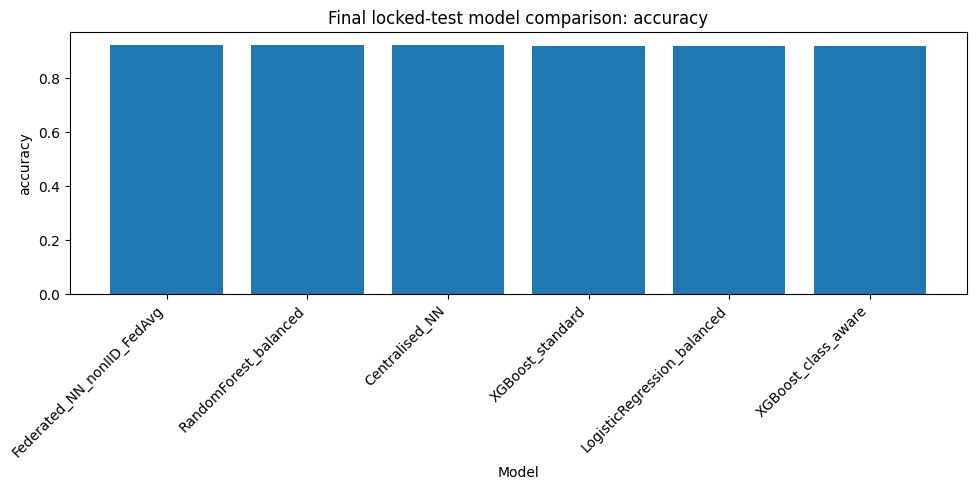

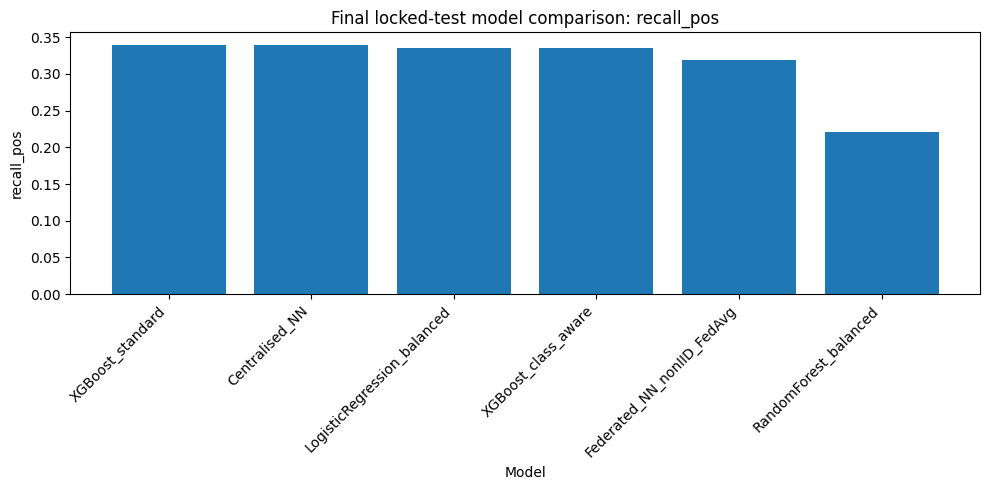

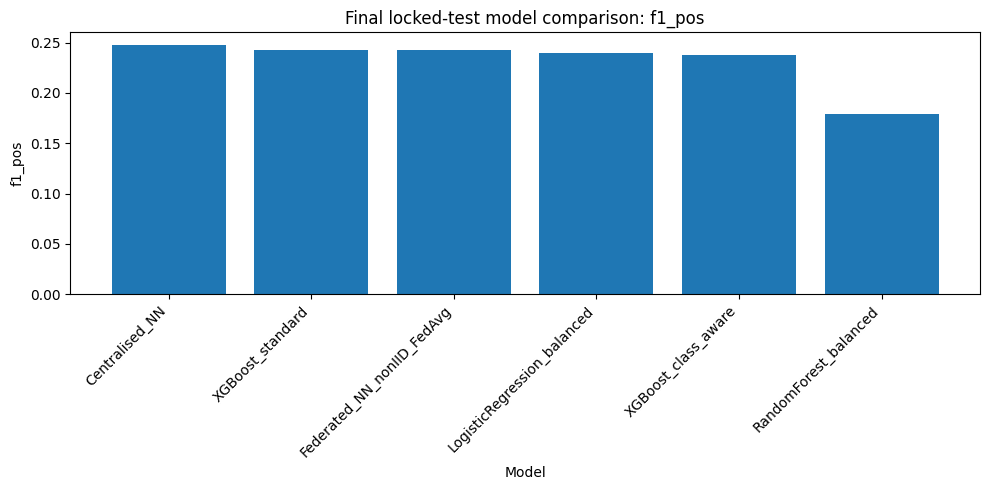

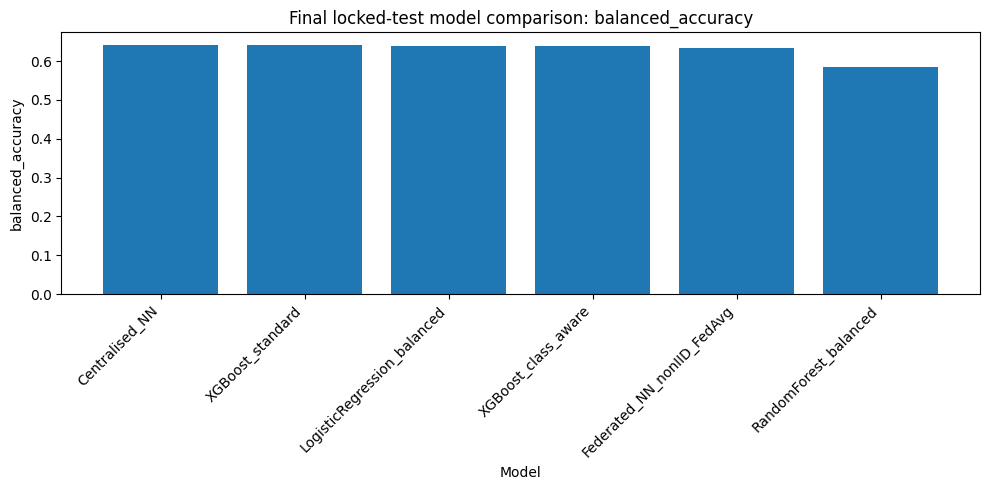

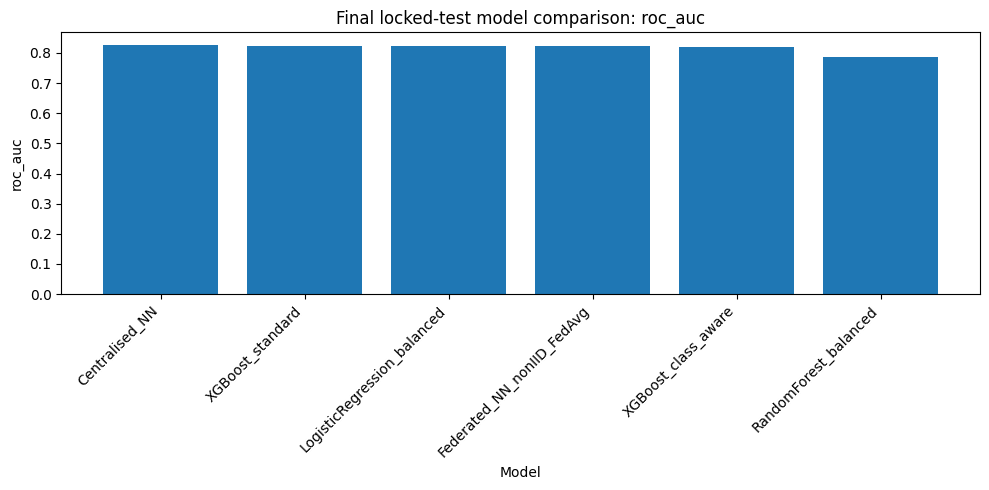

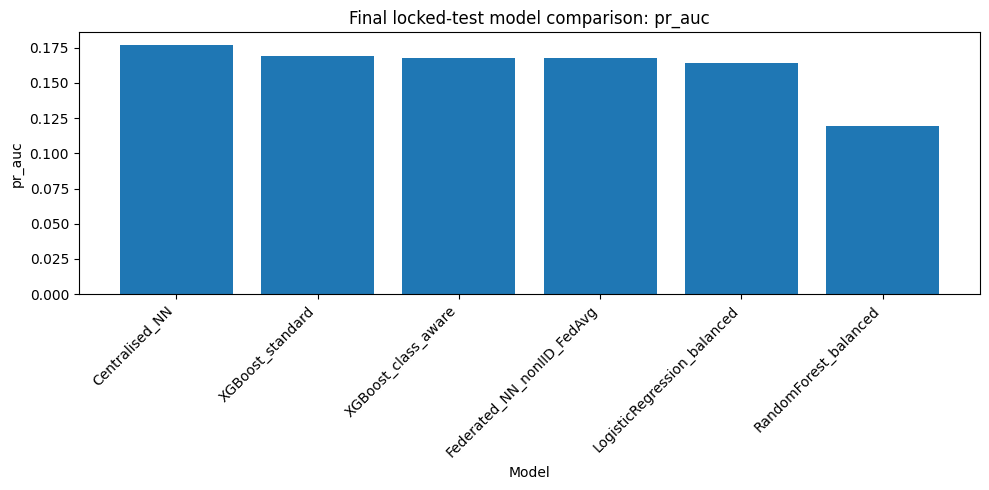

In [43]:

# 33A. Final locked-test model-comparison charts
for metric in [
    "accuracy",
    "recall_pos",
    "f1_pos",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc",
]:
    plot_df = final_results.sort_values(
        metric,
        ascending=False
    )

    plt.figure(figsize=(10, 5))
    plt.bar(
        plot_df["model"],
        plot_df[metric]
    )
    plt.title(
        f"Final locked-test model comparison: {metric}"
    )
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [44]:
# 34. Expanded final UREC1 compliance checks
checks = {
    "Exact UREC1 dataset file loaded":
        Path(DATA_PATH).name == "heart_2020_cleaned.csv",
    "Expected 319,795 x 18 dataset structure":
        df.shape == (319795, 18),
    "Formal data dictionary saved":
        (OUTPUT_DIR / "data_dictionary.csv").exists(),
    "Missingness and duplicate audit completed":
        (OUTPUT_DIR / "dataset_audit.csv").exists(),
    "Explicit plausibility checks saved":
        (OUTPUT_DIR / "plausibility_checks.csv").exists(),
    "Stroke is the target":
        "Stroke" not in X.columns,
    "Train/validation/test created":
        len(X_train) > 0 and len(X_val) > 0 and len(X_test) > 0,
    "Stratified prevalence is stable":
        abs(y_train.mean() - y_test.mean()) < 0.005,
    "Logistic Regression included":
        any("LogisticRegression" in x for x in trained_models),
    "Random Forest included":
        any("RandomForest" in x for x in trained_models),
    "Gradient boosting included":
        (
            any("XGBoost" in x for x in trained_models)
            if XGBOOST_AVAILABLE
            else False
        ),
    "Core UREC1 metrics reported":
        all(
            metric in final_results.columns
            for metric in [
                "pr_auc",
                "roc_auc",
                "recall_pos",
                "precision_pos",
                "macro_f1",
                "balanced_accuracy",
                "brier",
            ]
        ),
    "Centralised NN confusion matrix saved":
        (OUTPUT_DIR / "confusion_matrix_Centralised_NN.csv").exists(),
    "Federated NN confusion matrix saved":
        (
            OUTPUT_DIR
            / "confusion_matrix_Federated_NN_nonIID_FedAvg.csv"
        ).exists(),
    "Federated FedAvg experiment completed":
        len(fed_history) == FED_ROUNDS,
    "Sex/Age/Race subgroup metrics generated":
        set(["Sex", "AgeCategory", "Race"]).issubset(
            set(fairness_results["attribute"].unique())
        ),
    "SHAP attempted":
        True,
    "Software versions saved":
        (OUTPUT_DIR / "software_versions.csv").exists(),
    "Complete experiment settings saved":
        (OUTPUT_DIR / "experiment_settings.json").exists(),
    "Locked test results saved":
        (OUTPUT_DIR / "FINAL_model_comparison.csv").exists(),
}

check_df = pd.DataFrame({
    "requirement": list(checks.keys()),
    "passed": list(checks.values())
})
display(check_df)

check_df.to_csv(
    OUTPUT_DIR / "UREC1_compliance_checklist.csv",
    index=False
)

selected_accuracy = float(
    final_results.loc[
        final_results["model"] == BEST_CENTRAL_NAME,
        "accuracy"
    ].iloc[0]
)

print("\nSelected central model:", BEST_CENTRAL_NAME)
print("Locked-test accuracy:", f"{selected_accuracy:.2%}")

if selected_accuracy >= 0.90:
    print("90%+ overall locked-test accuracy achieved.")
else:
    print(
        "Overall locked-test accuracy is below 90%. "
        "Do not tune on the test set."
    )

print(
    "\nUREC1 checks passed:",
    int(check_df["passed"].sum()),
    "/",
    len(check_df)
)

,requirement,passed
0,Exact UREC1 dataset file loaded,True
1,"Expected 319,795 x 18 dataset structure",True
2,Formal data dictionary saved,True
3,Missingness and duplicate audit completed,True
4,Explicit plausibility checks saved,True
5,Stroke is the target,True
6,Train/validation/test created,True
7,Stratified prevalence is stable,True
8,Logistic Regression included,True
9,Random Forest included,True



Selected central model: XGBoost_standard
Locked-test accuracy: 92.01%
90%+ overall locked-test accuracy achieved.

UREC1 checks passed: 20 / 20


# Dissertation interpretation checklist

1. **Do not present accuracy alone.** Compare it with PR-AUC, stroke recall, positive-class F1, macro-F1 and balanced accuracy.
2. Explain why high accuracy is relatively easy in an imbalanced dataset and compare it with the no-information baseline.
3. State that threshold selection was performed using validation data only.
4. Treat the test set as locked and avoid repeated test-set tuning.
5. Explain that the federated experiment is a **simulation** with artificial clients, not deployment across hospitals.
6. Explain how the Dirichlet client split creates non-IID data.
7. Compare the centralised and federated neural networks using identical features and the same locked test set.
8. Discuss Brier score and calibration curves alongside discrimination metrics.
9. Report subgroup sample sizes before interpreting sex, age or race performance differences.
10. Treat SHAP as model explanation, not causal evidence.
11. Discuss the limitations of cross-sectional, self-reported BRFSS variables.
12. Do not claim that the model predicts an individual's future stroke or provides clinical diagnosis/treatment.

In [45]:
# 35. Create separate ZIP files for all figures and all analytical outputs
import os
import shutil
from IPython.display import FileLink, display

# Hardware/software details available after PyTorch was imported.
hardware_environment = {
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_version": torch.version.cuda,
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
}
with open(
    OUTPUT_DIR / "hardware_environment.json",
    "w"
) as f:
    json.dump(hardware_environment, f, indent=2)

# Create a concise run summary.
selected_row = final_results.loc[
    final_results["model"] == BEST_CENTRAL_NAME
].iloc[0]

run_summary = [
    "FINAL UREC1-ALIGNED RUN SUMMARY",
    "=" * 45,
    f"Dataset: {Path(DATA_PATH).name}",
    f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns",
    f"Target: Stroke",
    f"Dataset SHA-256: {DATA_SHA256}",
    f"Selected central model: {BEST_CENTRAL_NAME}",
    f"Locked-test accuracy: {selected_row['accuracy']:.6f}",
    f"Locked-test PR-AUC: {selected_row['pr_auc']:.6f}",
    f"Locked-test ROC-AUC: {selected_row['roc_auc']:.6f}",
    f"Stroke recall: {selected_row['recall_pos']:.6f}",
    f"Macro-F1: {selected_row['macro_f1']:.6f}",
    f"Balanced accuracy: {selected_row['balanced_accuracy']:.6f}",
    f"Centralised NN accuracy: {central_nn_test_metrics['accuracy']:.6f}",
    f"Federated NN accuracy: {fed_test_metrics['accuracy']:.6f}",
    f"All UREC1 checks passed: {bool(check_df['passed'].all())}",
    "",
    "Ethical/interpretive boundary:",
    "Academic cross-sectional stroke-status classification prototype only.",
    "Not clinical diagnosis, prospective individual future-stroke prediction,",
    "treatment recommendation, healthcare deployment or a medical device.",
]
with open(
    OUTPUT_DIR / "RUN_SUMMARY.txt",
    "w"
) as f:
    f.write("\n".join(run_summary))

# Figure manifest.
figure_files = [
    p for p in sorted(FIGURE_DIR.iterdir())
    if p.is_file()
]
pd.DataFrame({
    "file": [p.name for p in figure_files],
    "bytes": [p.stat().st_size for p in figure_files],
}).to_csv(
    OUTPUT_DIR / "figure_manifest.csv",
    index=False
)

# Output manifest.
output_files = [
    p for p in sorted(OUTPUT_DIR.iterdir())
    if p.is_file()
]
pd.DataFrame({
    "file": [p.name for p in output_files],
    "bytes": [p.stat().st_size for p in output_files],
}).to_csv(
    OUTPUT_DIR / "output_manifest.csv",
    index=False
)

FIGURES_ZIP = Path(
    "/kaggle/working/UREC1_ALL_GRAPHS_CHARTS_IMAGES.zip"
)
OUTPUTS_ZIP = Path(
    "/kaggle/working/UREC1_ALL_OUTPUTS.zip"
)

for zip_file in [FIGURES_ZIP, OUTPUTS_ZIP]:
    if zip_file.exists():
        zip_file.unlink()

# ZIP 1: every automatically saved displayed figure.
shutil.make_archive(
    str(FIGURES_ZIP.with_suffix("")),
    "zip",
    root_dir=str(FIGURE_DIR.parent),
    base_dir=FIGURE_DIR.name,
)

# ZIP 2: analytical outputs only. Exclude image formats because they are
# already supplied separately in the figures ZIP.
temp_output_package = Path(
    "/kaggle/working/_urec1_output_package"
)
if temp_output_package.exists():
    shutil.rmtree(temp_output_package)
temp_output_package.mkdir(parents=True)

image_extensions = {
    ".png", ".jpg", ".jpeg", ".webp",
    ".gif", ".svg", ".pdf"
}
for file_path in OUTPUT_DIR.iterdir():
    if (
        file_path.is_file()
        and file_path.suffix.lower() not in image_extensions
    ):
        shutil.copy2(
            file_path,
            temp_output_package / file_path.name
        )

shutil.make_archive(
    str(OUTPUTS_ZIP.with_suffix("")),
    "zip",
    root_dir=str(temp_output_package.parent),
    base_dir=temp_output_package.name,
)
shutil.rmtree(temp_output_package)

print("Final ZIP files created successfully.")
print(
    f"Figures ZIP: {FIGURES_ZIP} "
    f"({FIGURES_ZIP.stat().st_size / (1024**2):.2f} MB)"
)
print(
    f"Outputs ZIP: {OUTPUTS_ZIP} "
    f"({OUTPUTS_ZIP.stat().st_size / (1024**2):.2f} MB)"
)

print("\nDownload all graphs/charts/images:")
display(FileLink(str(FIGURES_ZIP)))

print("\nDownload all non-image analytical outputs and model artefacts:")
display(FileLink(str(OUTPUTS_ZIP)))

Final ZIP files created successfully.
Figures ZIP: /kaggle/working/UREC1_ALL_GRAPHS_CHARTS_IMAGES.zip (1.86 MB)
Outputs ZIP: /kaggle/working/UREC1_ALL_OUTPUTS.zip (1.39 MB)

Download all graphs/charts/images:


/kaggle/working/UREC1_ALL_GRAPHS_CHARTS_IMAGES.zip


Download all non-image analytical outputs and model artefacts:


/kaggle/working/UREC1_ALL_OUTPUTS.zip